**Salmon Fish Disease Classification**


This work uses the following public **dataset**:

Ahmed, Md Shoaib (2024), “SalmonScan: A Novel Image Dataset for Machine Learning and Deep Learning Analysis in Fish Disease Detection in Aquaculture”, Mendeley Data, V3.
DOI: 10.17632/x3fz2nfm4w.3
Dataset URL: https://data.mendeley.com/datasets/x3fz2nfm4w/3


The SalmonScan dataset contains salmon fish images categorized into two classes:

*   Fresh Salmon
*   Infected Salmon

The dataset is suitable for machine learning and deep learning-based fish disease detection in aquaculture systems.



Prepared by

Partha Pratim Ray, Sikkim University, India, May 24, 2026, parthapratimray1986@gmail.com, ppray@cus.ac.in

In [1]:
#Cell 1: Install libraries
!pip -q install timm ultralytics transformers accelerate torchmetrics scikit-learn seaborn opencv-python pillow pandas openpyxl statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 31.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 21.3 MB/s eta 0:00:00


In [2]:
# Cell 2: Imports and seed
import os, zipfile, shutil, time, random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import *
from statsmodels.stats.contingency_tables import mcnemar

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

import timm
from transformers import AutoModelForImageClassification

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

Device: cuda


In [3]:
# Cell 3: Download SalmonScan Version 3 and extract

DATA_DIR = Path("/content/salmonscan")
ZIP_PATH = Path("/content/salmonscan_v3.zip")

!rm -rf /content/salmonscan /content/salmonscan_v3.zip

!wget -O /content/salmonscan_v3.zip "https://data.mendeley.com/public-api/zip/x3fz2nfm4w/download/3"

print("Zip exists:", ZIP_PATH.exists())
print("Zip size MB:", ZIP_PATH.stat().st_size / (1024 * 1024))

DATA_DIR.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, "r") as z:
    print("First 50 zip entries:")
    for name in z.namelist()[:50]:
        print(name)
    z.extractall(DATA_DIR)

print("Extraction completed.")

--2026-05-29 09:52:17--  https://data.mendeley.com/public-api/zip/x3fz2nfm4w/download/3
Resolving data.mendeley.com (data.mendeley.com)... 162.159.130.86, 162.159.133.86
Connecting to data.mendeley.com (data.mendeley.com)|162.159.130.86|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://prod-dcd-datasets-cache-zipfiles.s3.eu-west-1.amazonaws.com/x3fz2nfm4w-3.zip?X-Amz-Security-Token=IQoJb3JpZ2luX2VjEPr%2F%2F%2F%2F%2F%2F%2F%2F%2F%2FwEaCWV1LXdlc3QtMSJHMEUCIQClG63t6fmV69B9gGHtukthYoNyslAN5wA2dlSS%2Bj3MJQIgc73Yd91i0UwrqvtS245WMTHldcwiQJMPSMpba%2BB5dvMqlQUIw%2F%2F%2F%2F%2F%2F%2F%2F%2F%2F%2FARAEGgwzNjcxNDczODM4MjUiDHnTUo2gzgw26XyJ0CrpBI4CvJ%2B%2B4LBFUUTyQVOgCjZ15XaW%2BarRKp0VxF3w0O7vS3vePcWQizI3CZU4iP8STJ1MtRUVpr5W35uiMO4lYcR5TXMJVNKRQ7PNPqRuKIjhf%2BpFXSVIaUdWypGTvWS0Bc0DAMAc%2F0Dqe1vaUy7GwloAFlbR%2Fwzz09iqVw9Gh6iAmJTV7OVbd3b7b4Twm2UR1hpYz1EGsfPZQHi3tb7LhfRLakCiBPxTfUks%2B1nEklFCxxWhwJYW3EurzDK7TIfKF75QN5svt4nB9PBS7Yi8vRCh1pen6SWvtb%2BwFex6erOiEfVLuX83jZ7M

In [4]:
# Cell 4: Extract nested SalmonScan.zip and discover images

INNER_ZIP = list(DATA_DIR.rglob("SalmonScan.zip"))

print("Nested zip files found:", INNER_ZIP)

if len(INNER_ZIP) == 0:
    raise ValueError("No nested SalmonScan.zip found.")

INNER_EXTRACT_DIR = DATA_DIR / "SalmonScan_extracted"
INNER_EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(INNER_ZIP[0], "r") as z:
    print("First 50 entries inside nested zip:")
    for name in z.namelist()[:50]:
        print(name)
    z.extractall(INNER_EXTRACT_DIR)

image_exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tif", ".tiff"}

image_paths = [
    p for p in INNER_EXTRACT_DIR.rglob("*")
    if p.is_file() and p.suffix.lower() in image_exts
]

print("Total image files found:", len(image_paths))

if len(image_paths) == 0:
    print("Folder tree sample:")
    for p in list(INNER_EXTRACT_DIR.rglob("*"))[:150]:
        print(p)
    raise ValueError("No images found inside nested zip.")

df = pd.DataFrame({"path": [str(p) for p in image_paths]})

def infer_label(path):
    s = str(path).lower()

    if "infected" in s or "infect" in s or "disease" in s:
        return "InfectedFish"
    elif "fresh" in s or "healthy" in s:
        return "FreshFish"
    else:
        return "Unknown"

df["label"] = df["path"].apply(infer_label)

print("\nDetected labels:")
print(df["label"].value_counts())

print("\nSample rows:")
print(df.head(10).to_string(index=False))

Nested zip files found: [PosixPath('/content/salmonscan/SalmonScan A Novel Image Dataset for Machine Learning and Deep Learning Analysis in Fish Disease Detection in Aquaculture/SalmonScan.zip')]
First 50 entries inside nested zip:
SalmonScan/Augmented/
SalmonScan/Augmented/FreshFish/
SalmonScan/Augmented/FreshFish/fresh_0.png
SalmonScan/Augmented/FreshFish/fresh_1.png
SalmonScan/Augmented/FreshFish/fresh_10.png
SalmonScan/Augmented/FreshFish/fresh_100.png
SalmonScan/Augmented/FreshFish/fresh_101.png
SalmonScan/Augmented/FreshFish/fresh_102.png
SalmonScan/Augmented/FreshFish/fresh_103.png
SalmonScan/Augmented/FreshFish/fresh_104.png
SalmonScan/Augmented/FreshFish/fresh_105.png
SalmonScan/Augmented/FreshFish/fresh_106.png
SalmonScan/Augmented/FreshFish/fresh_107.png
SalmonScan/Augmented/FreshFish/fresh_108.png
SalmonScan/Augmented/FreshFish/fresh_109.png
SalmonScan/Augmented/FreshFish/fresh_11.png
SalmonScan/Augmented/FreshFish/fresh_110.png
SalmonScan/Augmented/FreshFish/fresh_111.png


In [5]:
# Cell 5: Train/validation/test split

WORK_DIR = Path("/content/salmon_ready")

if WORK_DIR.exists():
    shutil.rmtree(WORK_DIR)

for split in ["train", "val", "test"]:
    for cls in ["FreshFish", "InfectedFish"]:
        (WORK_DIR / split / cls).mkdir(parents=True, exist_ok=True)

train_df, temp_df = train_test_split(
    df, test_size=0.30, stratify=df["label"], random_state=SEED
)

val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df["label"], random_state=SEED
)

for split_name, split_df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    for _, row in split_df.iterrows():
        src = Path(row["path"])
        dst = WORK_DIR / split_name / row["label"] / src.name
        shutil.copy2(src, dst)

dist = []
for split in ["train", "val", "test"]:
    for cls in ["FreshFish", "InfectedFish"]:
        dist.append({
            "Split": split,
            "Class": cls,
            "Count": len(list((WORK_DIR / split / cls).glob("*")))
        })

dist_df = pd.DataFrame(dist)
print(dist_df.to_string(index=False))

Split        Class  Count
train    FreshFish    335
train InfectedFish    590
  val    FreshFish     72
  val InfectedFish    126
 test    FreshFish     72
 test InfectedFish    127


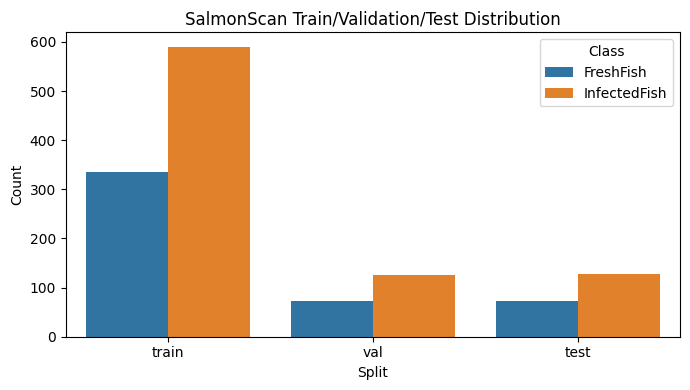

In [6]:
# Cell 6: Plot class distribution

plt.figure(figsize=(7,4))
sns.barplot(data=dist_df, x="Split", y="Count", hue="Class")
plt.title("SalmonScan Train/Validation/Test Distribution")
plt.tight_layout()
plt.show()

In [7]:
# Cell 7: Data loaders

IMG_SIZE = 224
BATCH_SIZE = 32

train_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.10),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225])
])

eval_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225])
])

train_ds = datasets.ImageFolder(WORK_DIR / "train", transform=train_tfms)
val_ds   = datasets.ImageFolder(WORK_DIR / "val", transform=eval_tfms)
test_ds  = datasets.ImageFolder(WORK_DIR / "test", transform=eval_tfms)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

class_names = train_ds.classes
num_classes = len(class_names)

print(class_names)

['FreshFish', 'InfectedFish']


In [8]:
# Cell 8: Model factory with basic CNN + recent models

def build_model(model_name, num_classes=2):

    # Basic CNN / classical transfer-learning baselines
    if model_name == "alexnet":
        model = models.alexnet(weights=models.AlexNet_Weights.IMAGENET1K_V1)
        model.classifier[-1] = nn.Linear(model.classifier[-1].in_features, num_classes)

    elif model_name == "vgg16":
        model = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
        model.classifier[-1] = nn.Linear(model.classifier[-1].in_features, num_classes)

    elif model_name == "vgg19":
        model = models.vgg19(weights=models.VGG19_Weights.IMAGENET1K_V1)
        model.classifier[-1] = nn.Linear(model.classifier[-1].in_features, num_classes)

    elif model_name == "resnet18":
        model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        model.fc = nn.Linear(model.fc.in_features, num_classes)

    elif model_name == "resnet50":
        model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
        model.fc = nn.Linear(model.fc.in_features, num_classes)

    elif model_name == "densenet121":
        model = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)
        model.classifier = nn.Linear(model.classifier.in_features, num_classes)

    elif model_name == "inception_v3":
        model = models.inception_v3(weights=models.Inception_V3_Weights.IMAGENET1K_V1, aux_logits=True)
        model.fc = nn.Linear(model.fc.in_features, num_classes)

    elif model_name == "efficientnet_b0":
        model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
        model.classifier[-1] = nn.Linear(model.classifier[-1].in_features, num_classes)

    # Recent lightweight timm model from Hugging Face
    elif model_name == "hf_mobilenetv3_small_lamb":
        model = timm.create_model(
            "hf_hub:timm/mobilenetv3_small_100.lamb_in1k",
            pretrained=True,
            num_classes=num_classes
        )

    # Vision transformer baselines
    elif model_name == "vit_base":
        model = timm.create_model(
            "vit_base_patch16_224",
            pretrained=True,
            num_classes=num_classes
        )

    elif model_name == "swinv2_tiny":
        model = timm.create_model(
            "swinv2_tiny_window8_256",
            pretrained=True,
            num_classes=num_classes
        )

    # Domain-unrelated but requested HF ViT model; useful only as transfer baseline
    elif model_name == "falconsai_nsfw_vit":
        model = AutoModelForImageClassification.from_pretrained(
            "Falconsai/nsfw_image_detection",
            num_labels=num_classes,
            ignore_mismatched_sizes=True
        )

    else:
        raise ValueError(f"Unknown model: {model_name}")

    return model.to(DEVICE)

In [9]:
# Cell 9: Training loop

def forward_logits(model, x):
    out = model(x)
    if hasattr(out, "logits"):
        return out.logits
    if isinstance(out, tuple):
        return out[0]
    return out


def run_one_epoch(model, loader, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    criterion = nn.CrossEntropyLoss()
    total_loss = 0
    all_y, all_pred, all_prob = [], [], []

    with torch.set_grad_enabled(is_train):
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)

            logits = forward_logits(model, x)
            loss = criterion(logits, y)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            probs = torch.softmax(logits, dim=1)[:, 1]
            preds = torch.argmax(logits, dim=1)

            total_loss += loss.item() * x.size(0)
            all_y.extend(y.cpu().numpy())
            all_pred.extend(preds.cpu().numpy())
            all_prob.extend(probs.detach().cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_y, all_pred)
    f1 = f1_score(all_y, all_pred)

    return avg_loss, acc, f1, np.array(all_y), np.array(all_pred), np.array(all_prob)


def train_model(model_name, epochs=10, lr=1e-4):
    model = build_model(model_name, num_classes)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=1e-4
    )

    history = []
    best_f1 = -1
    best_path = f"/content/best_{model_name}.pt"

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc, tr_f1, *_ = run_one_epoch(model, train_loader, optimizer)
        va_loss, va_acc, va_f1, *_ = run_one_epoch(model, val_loader)

        row = {
            "epoch": epoch,
            "train_loss": tr_loss,
            "val_loss": va_loss,
            "train_acc": tr_acc,
            "val_acc": va_acc,
            "train_f1": tr_f1,
            "val_f1": va_f1
        }

        history.append(row)
        print(row)

        if va_f1 > best_f1:
            best_f1 = va_f1
            torch.save(model.state_dict(), best_path)

    model.load_state_dict(torch.load(best_path, map_location=DEVICE))
    return model, pd.DataFrame(history), best_path

In [10]:
# Cell 10: Select models to run

MODELS_TO_RUN = [
    # Basic CNN baselines
    "alexnet",
    "vgg16",
    "vgg19",
    "resnet18",
    "resnet50",
    "densenet121",
    "efficientnet_b0",

    # Recent/lightweight/requested models
    "hf_mobilenetv3_small_lamb",

    # Transformer models
    "vit_base",

    # Requested HF transfer baseline
    "falconsai_nsfw_vit"
]

all_histories = {}
trained_models = {}

for m in MODELS_TO_RUN:
    print("\n" + "="*80)
    print("Training:", m)
    print("="*80)

    try:
        model, hist, path = train_model(m, epochs=20, lr=1e-4)
        all_histories[m] = hist
        trained_models[m] = model
    except Exception as e:
        print(f"Skipped {m} due to error: {e}")


Training: alexnet
Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:03<00:00, 69.0MB/s]


{'epoch': 1, 'train_loss': 0.3314822953456157, 'val_loss': 0.13479600726354002, 'train_acc': 0.8540540540540541, 'val_acc': 0.9444444444444444, 'train_f1': 0.8864592094196804, 'val_f1': 0.9571984435797666}
{'epoch': 2, 'train_loss': 0.15186628858785373, 'val_loss': 0.11723479959699842, 'train_acc': 0.9437837837837838, 'val_acc': 0.9393939393939394, 'train_f1': 0.9564489112227805, 'val_f1': 0.9512195121951219}
{'epoch': 3, 'train_loss': 0.12697772452154676, 'val_loss': 0.12412452185996856, 'train_acc': 0.9481081081081081, 'val_acc': 0.9444444444444444, 'train_f1': 0.9597989949748744, 'val_f1': 0.9547325102880658}
{'epoch': 4, 'train_loss': 0.12469687789678574, 'val_loss': 0.053309848212232495, 'train_acc': 0.9545945945945946, 'val_acc': 0.98989898989899, 'train_f1': 0.9645868465430016, 'val_f1': 0.9921259842519685}
{'epoch': 5, 'train_loss': 0.09643485507449588, 'val_loss': 0.07520235521775304, 'train_acc': 0.9654054054054054, 'val_acc': 0.9696969696969697, 'train_f1': 0.973018549747048

100%|██████████| 528M/528M [00:03<00:00, 154MB/s]


{'epoch': 1, 'train_loss': 0.30458923927030046, 'val_loss': 0.18723144629650346, 'train_acc': 0.8637837837837837, 'val_acc': 0.9343434343434344, 'train_f1': 0.8944723618090452, 'val_f1': 0.9501915708812261}
{'epoch': 2, 'train_loss': 0.1799724939384976, 'val_loss': 0.07480279235827803, 'train_acc': 0.9351351351351351, 'val_acc': 0.9797979797979798, 'train_f1': 0.9494949494949495, 'val_f1': 0.9841269841269841}
{'epoch': 3, 'train_loss': 0.11749855129299937, 'val_loss': 0.07810264767260489, 'train_acc': 0.9567567567567568, 'val_acc': 0.9595959595959596, 'train_f1': 0.9658703071672355, 'val_f1': 0.9692307692307692}
{'epoch': 4, 'train_loss': 0.08853090040989824, 'val_loss': 0.0662957343244643, 'train_acc': 0.9621621621621622, 'val_acc': 0.9696969696969697, 'train_f1': 0.970513900589722, 'val_f1': 0.9763779527559056}
{'epoch': 5, 'train_loss': 0.10053426457417977, 'val_loss': 0.07952128094856185, 'train_acc': 0.9675675675675676, 'val_acc': 0.9797979797979798, 'train_f1': 0.9745762711864406

...

{'epoch': 1, 'train_loss': 0.378278206909025, 'val_loss': 0.14762437678497248, 'train_acc': 0.8356756756756757, 'val_acc': 0.9444444444444444, 'train_f1': 0.8737541528239202, 'val_f1': 0.9581749049429658}
{'epoch': 2, 'train_loss': 0.2344431417536091, 'val_loss': 0.1692782413176816, 'train_acc': 0.907027027027027, 'val_acc': 0.9242424242424242, 'train_f1': 0.9278523489932886, 'val_f1': 0.9416342412451362}
{'epoch': 3, 'train_loss': 0.20310482800812335, 'val_loss': 0.3327515787548489, 'train_acc': 0.9232432432432433, 'val_acc': 0.8181818181818182, 'train_f1': 0.9410788381742738, 'val_f1': 0.875}
{'epoch': 4, 'train_loss': 0.15413671105294613, 'val_loss': 0.11029810405740834, 'train_acc': 0.9308108108108109, 'val_acc': 0.9545454545454546, 'train_f1': 0.9458544839255499, 'val_f1': 0.9649805447470817}
{'epoch': 5, 'train_loss': 0.1402579370584037, 'val_loss': 0.11215661706948521, 'train_acc': 0.947027027027027, 'val_acc': 0.9444444444444444, 'train_f1': 0.9592006661115737, 'val_f1': 0.9571

config.json:   0%|          | 0.00/724 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/343M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

{'epoch': 1, 'train_loss': 0.3668914486024831, 'val_loss': 0.17280663625158446, 'train_acc': 0.8962162162162162, 'val_acc': 0.9191919191919192, 'train_f1': 0.918918918918919, 'val_f1': 0.9322033898305084}
{'epoch': 2, 'train_loss': 0.10820981167458199, 'val_loss': 0.2355985250135865, 'train_acc': 0.9556756756756757, 'val_acc': 0.8737373737373737, 'train_f1': 0.9652836579170194, 'val_f1': 0.8898678414096917}
{'epoch': 3, 'train_loss': 0.08179834168505025, 'val_loss': 0.07246079002365921, 'train_acc': 0.9578378378378378, 'val_acc': 0.9696969696969697, 'train_f1': 0.9666951323654995, 'val_f1': 0.976}
{'epoch': 4, 'train_loss': 0.047411663142360144, 'val_loss': 0.0826343001440318, 'train_acc': 0.9848648648648649, 'val_acc': 0.9494949494949495, 'train_f1': 0.9881154499151104, 'val_f1': 0.9586776859504132}
{'epoch': 5, 'train_loss': 0.05708956897661493, 'val_loss': 0.07552158772343337, 'train_acc': 0.9794594594594594, 'val_acc': 0.9797979797979798, 'train_f1': 0.9838022165387894, 'val_f1': 0

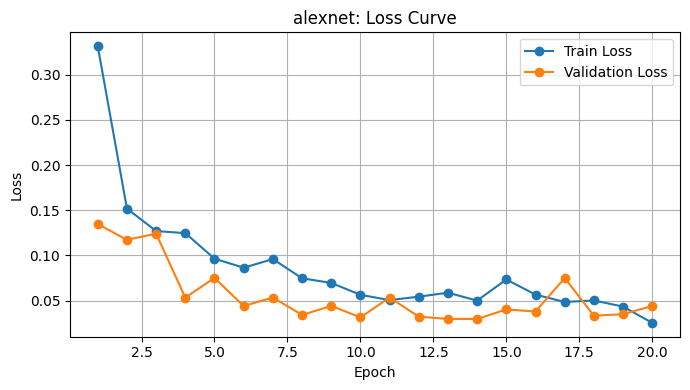

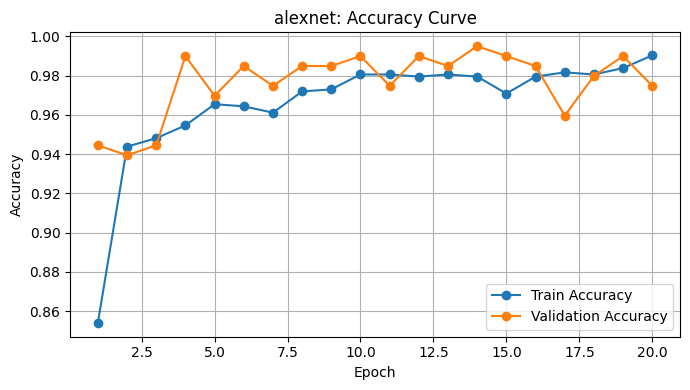

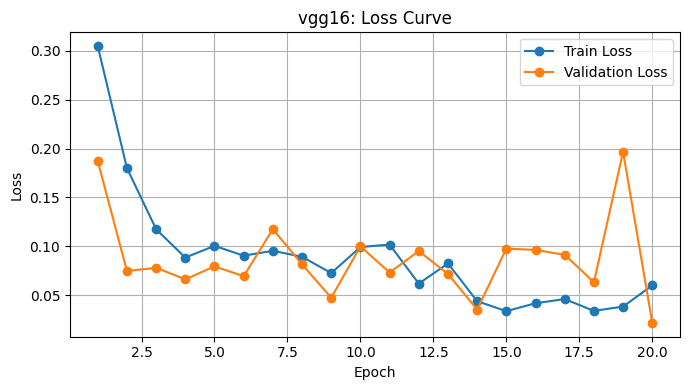

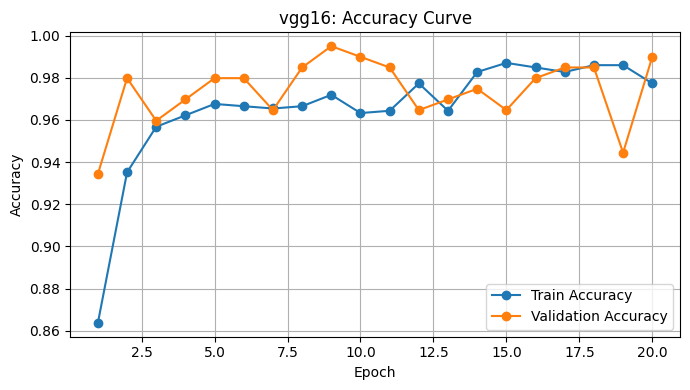

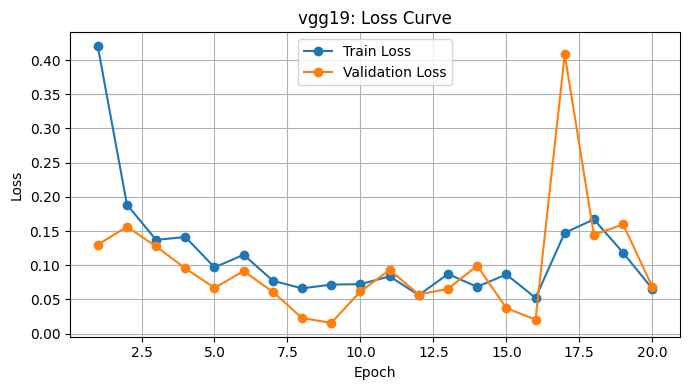

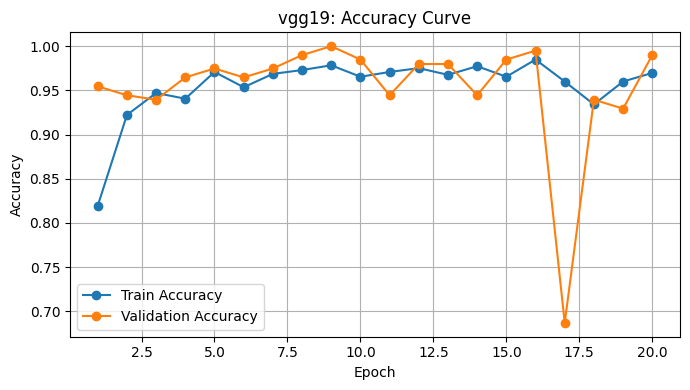

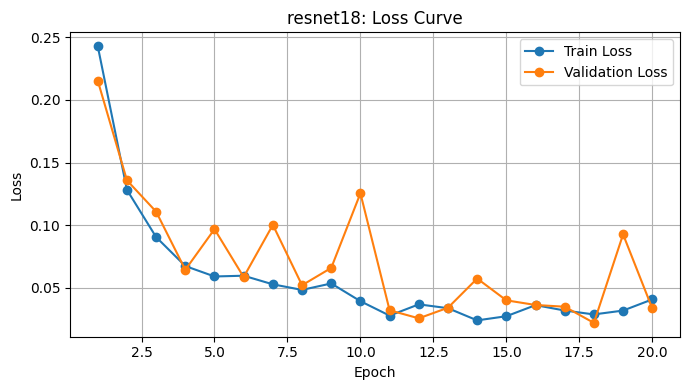

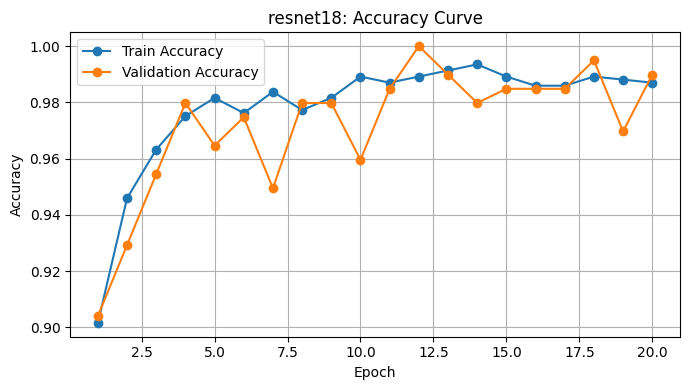

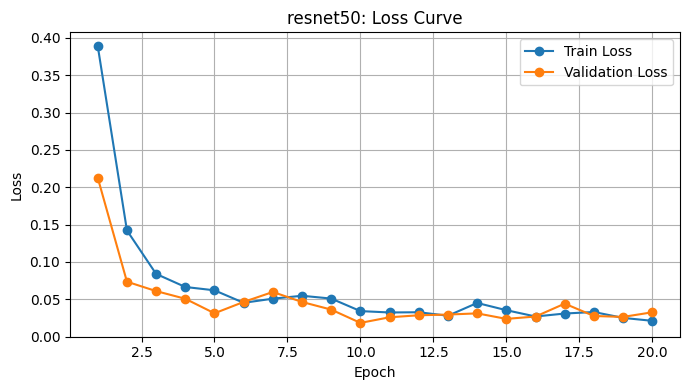

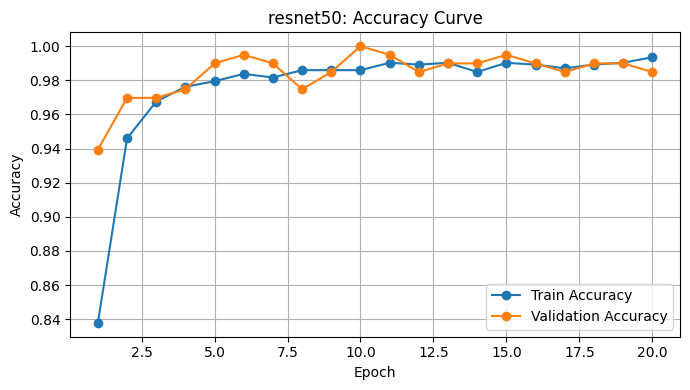

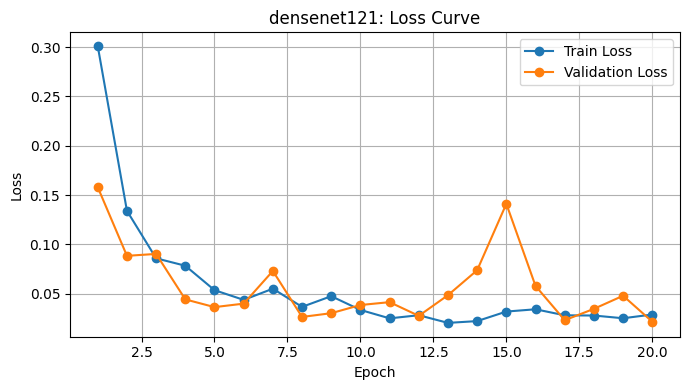

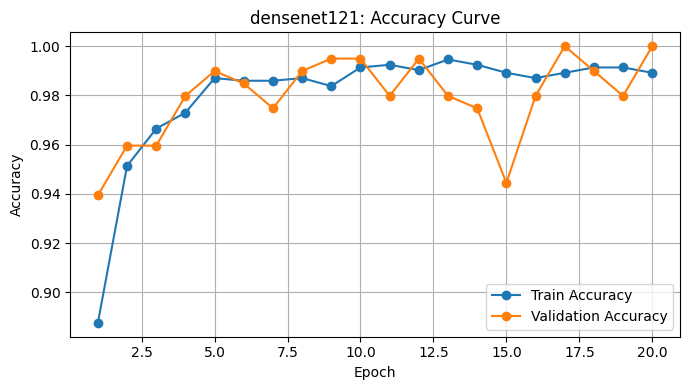

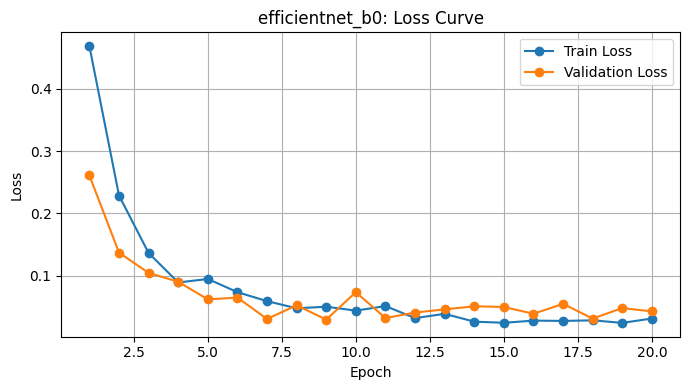

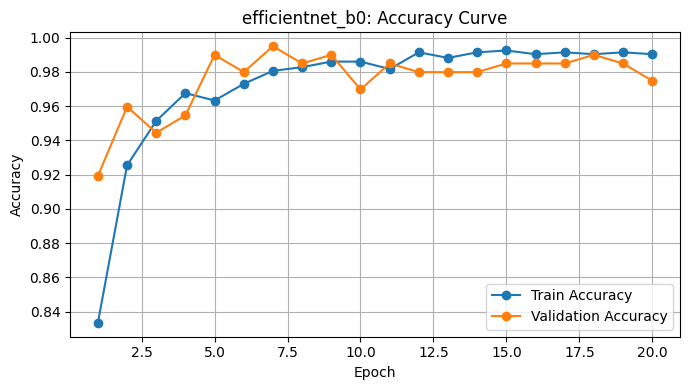

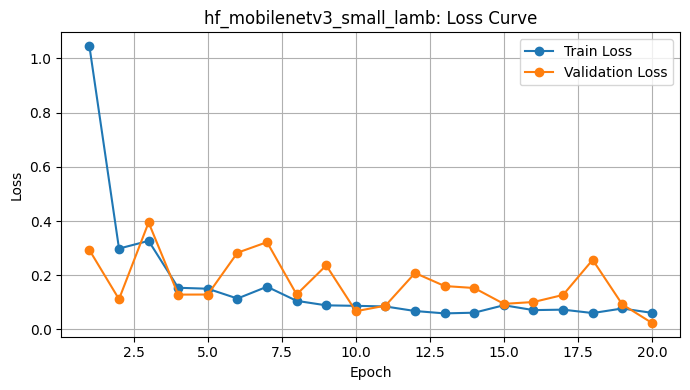

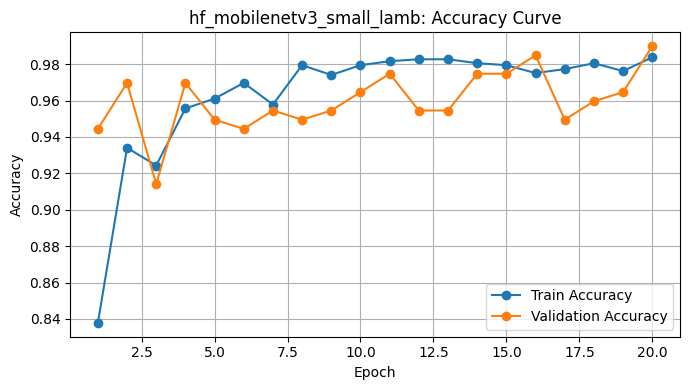

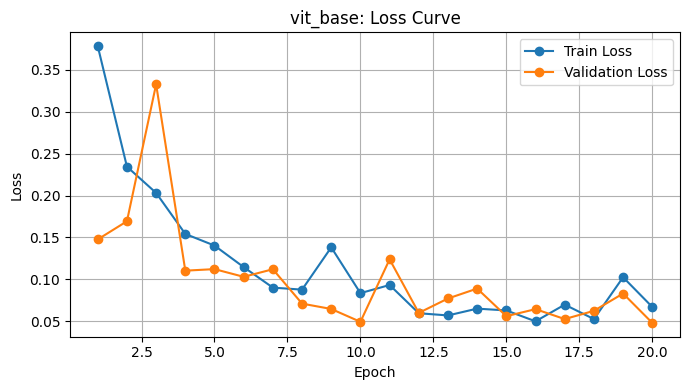

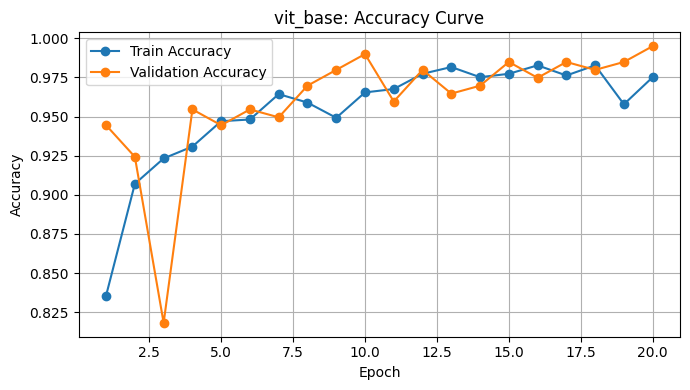

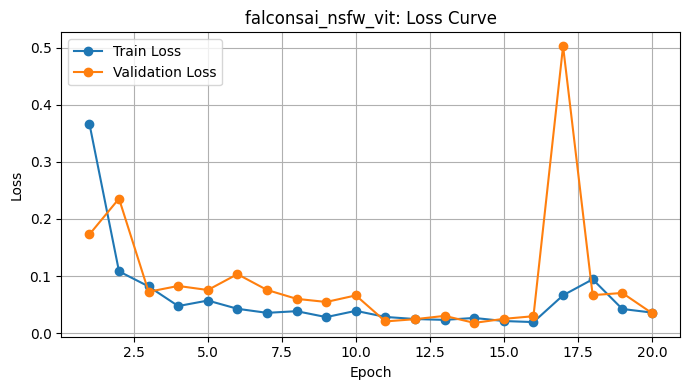

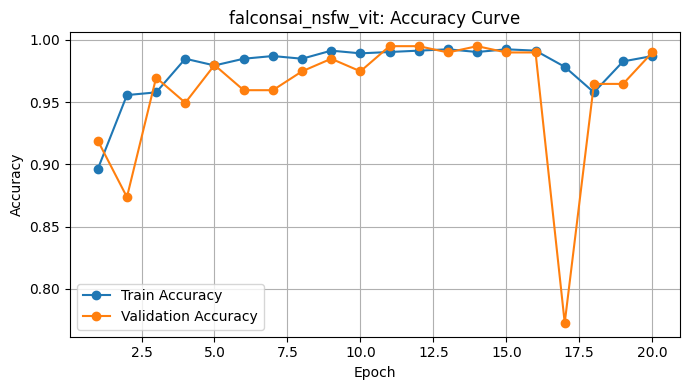

In [11]:
# Cell 11: Plot loss and accuracy

for model_name, hist in all_histories.items():

    plt.figure(figsize=(7,4))
    plt.plot(hist["epoch"], hist["train_loss"], marker="o", label="Train Loss")
    plt.plot(hist["epoch"], hist["val_loss"], marker="o", label="Validation Loss")
    plt.title(f"{model_name}: Loss Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7,4))
    plt.plot(hist["epoch"], hist["train_acc"], marker="o", label="Train Accuracy")
    plt.plot(hist["epoch"], hist["val_acc"], marker="o", label="Validation Accuracy")
    plt.title(f"{model_name}: Accuracy Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [12]:
# Cell 12: Test metrics

def compute_metrics(y_true, y_pred, y_prob):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    sensitivity = tp / (tp + fn + 1e-9)
    specificity = tn / (tn + fp + 1e-9)

    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall/Sensitivity": sensitivity,
        "Specificity": specificity,
        "F1-score": f1_score(y_true, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred),
        "MCC": matthews_corrcoef(y_true, y_pred),
        "Cohen Kappa": cohen_kappa_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_prob),
        "PR-AUC": average_precision_score(y_true, y_prob),
        "Brier Score": brier_score_loss(y_true, y_prob),
        "TP": tp,
        "TN": tn,
        "FP": fp,
        "FN": fn
    }


results = []
pred_store = {}

for model_name, model in trained_models.items():
    test_loss, test_acc, test_f1, y_true, y_pred, y_prob = run_one_epoch(model, test_loader)

    metrics = compute_metrics(y_true, y_pred, y_prob)
    metrics["Model"] = model_name
    metrics["Test Loss"] = test_loss

    results.append(metrics)
    pred_store[model_name] = {
        "y_true": y_true,
        "y_pred": y_pred,
        "y_prob": y_prob
    }

results_df = pd.DataFrame(results)

cols = [
    "Model", "Test Loss", "Accuracy", "Precision", "Recall/Sensitivity",
    "Specificity", "F1-score", "Balanced Accuracy", "MCC",
    "Cohen Kappa", "ROC-AUC", "PR-AUC", "Brier Score",
    "TP", "TN", "FP", "FN"
]

results_df = results_df[cols]
print(results_df.round(4).to_string(index=False))
results_df.to_csv("/content/salmon_model_test_metrics.csv", index=False)

                    Model  Test Loss  Accuracy  Precision  Recall/Sensitivity  Specificity  F1-score  Balanced Accuracy    MCC  Cohen Kappa  ROC-AUC  PR-AUC  Brier Score  TP  TN  FP  FN
                  alexnet     0.0997    0.9749     1.0000              0.9606       1.0000    0.9799             0.9803 0.9478       0.9464   0.9967  0.9982       0.0238 122  72   0   5
                    vgg16     0.0682    0.9598     0.9760              0.9606       0.9583    0.9683             0.9595 0.9137       0.9135   0.9970  0.9984       0.0246 122  69   3   5
                    vgg19     0.0267    0.9899     1.0000              0.9843       1.0000    0.9921             0.9921 0.9786       0.9784   0.9996  0.9998       0.0082 125  72   0   2
                 resnet18     0.0617    0.9849     0.9844              0.9921       0.9722    0.9882             0.9822 0.9673       0.9673   0.9975  0.9985       0.0151 126  70   2   1
                 resnet50     0.0431    0.9899     1.0000             

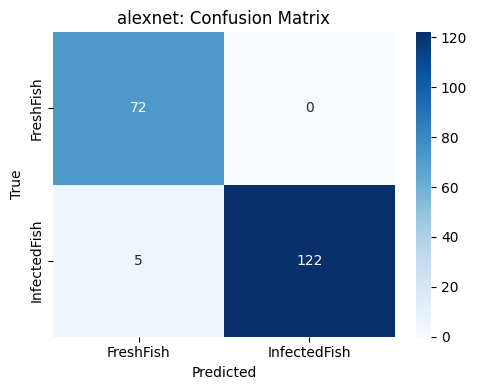

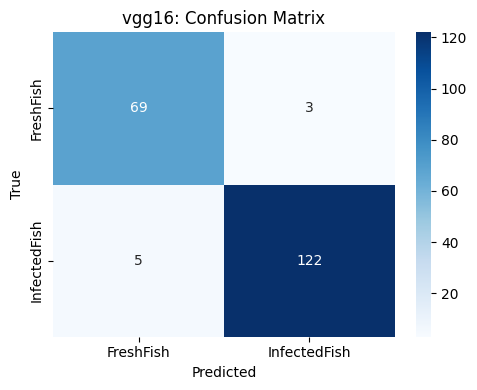

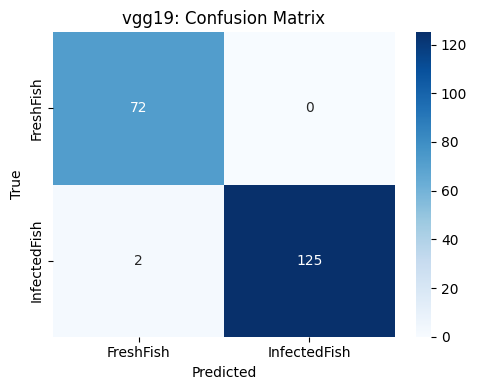

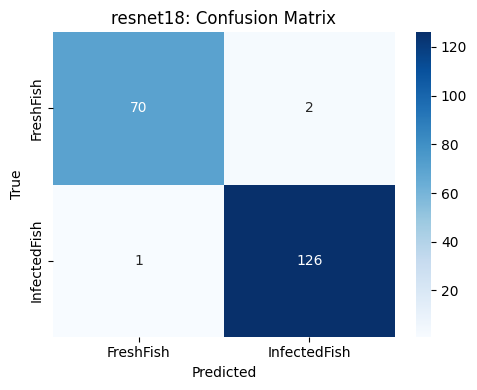

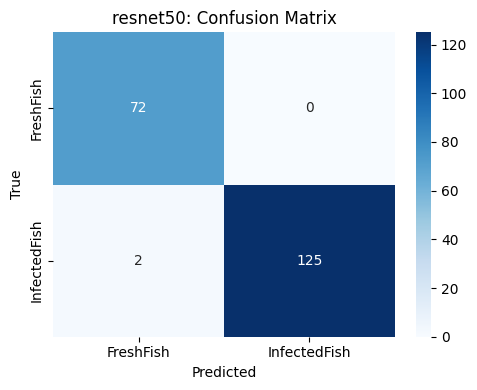

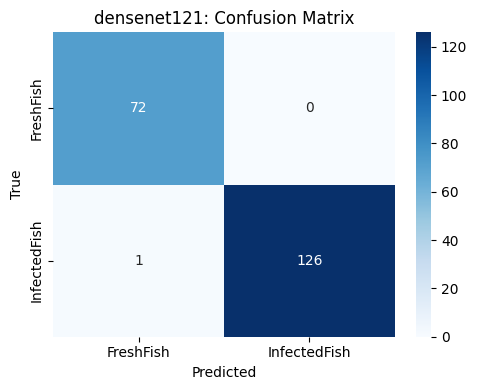

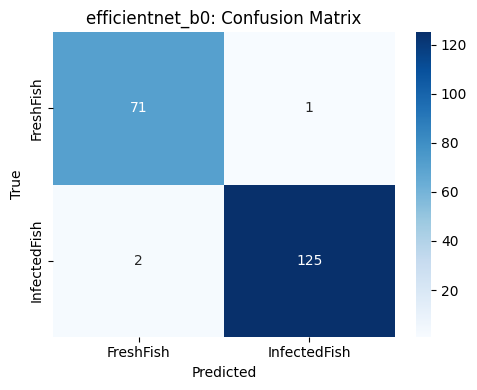

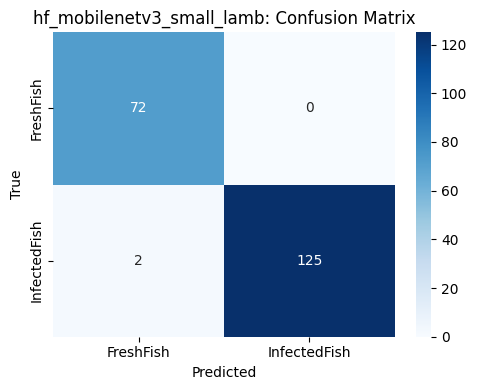

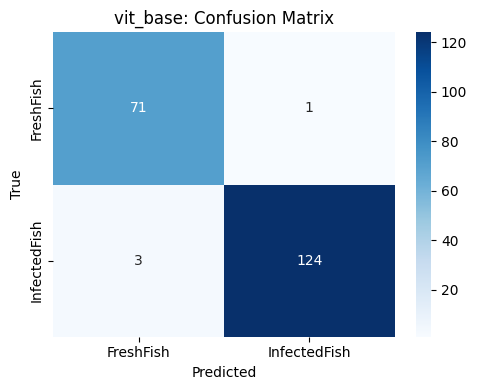

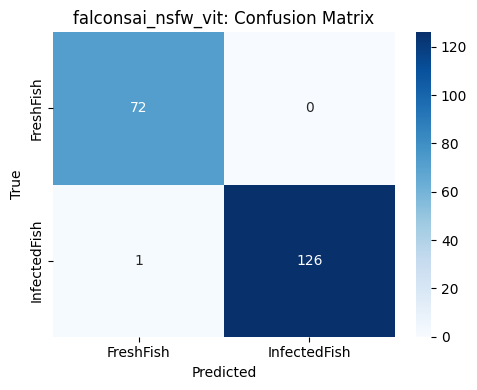

In [13]:
# Cell 13: Confusion matrices

for model_name, item in pred_store.items():
    cm = confusion_matrix(item["y_true"], item["y_pred"])

    plt.figure(figsize=(5,4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )
    plt.title(f"{model_name}: Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

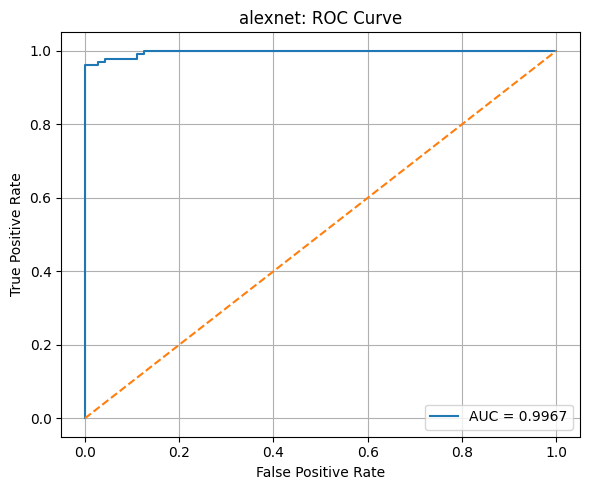

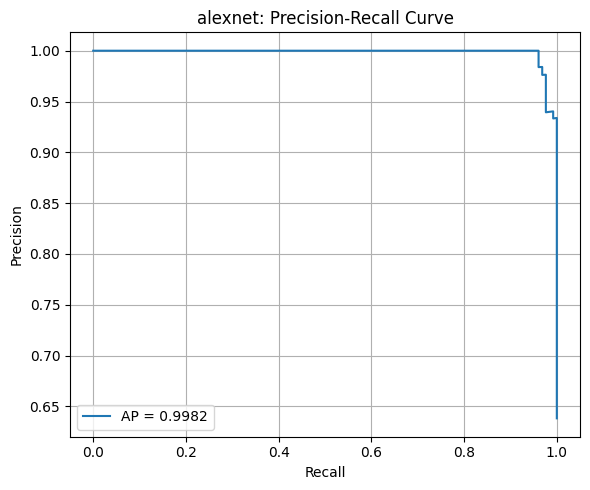

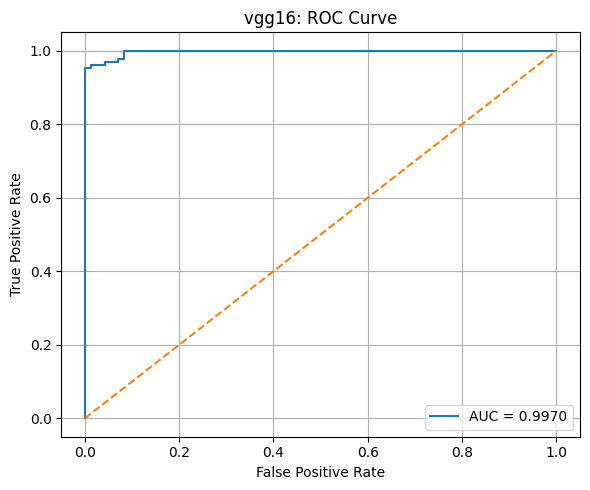

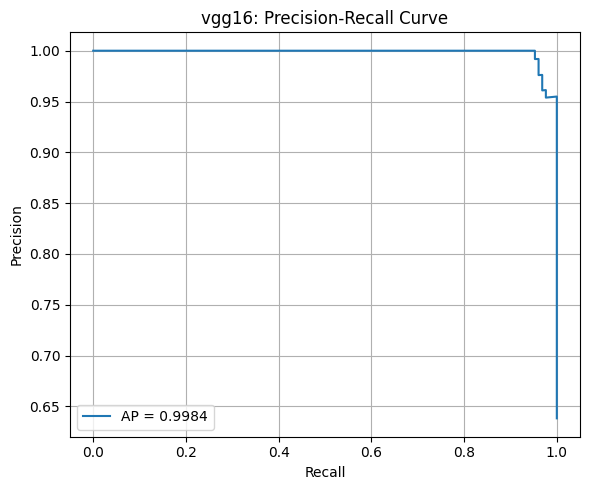

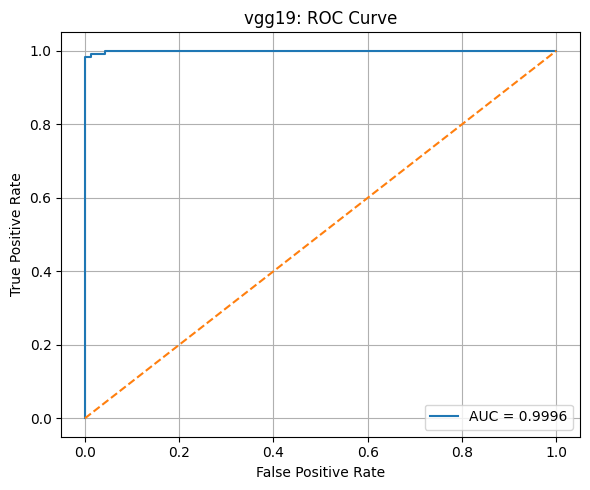

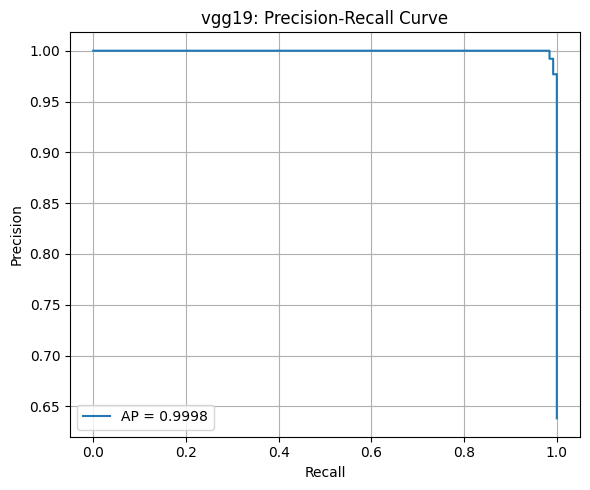

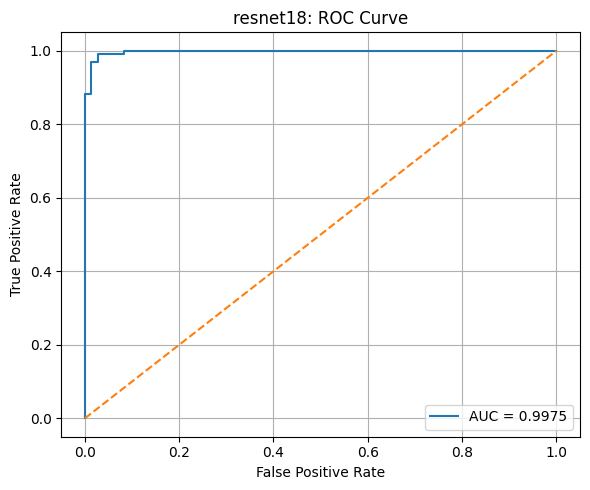

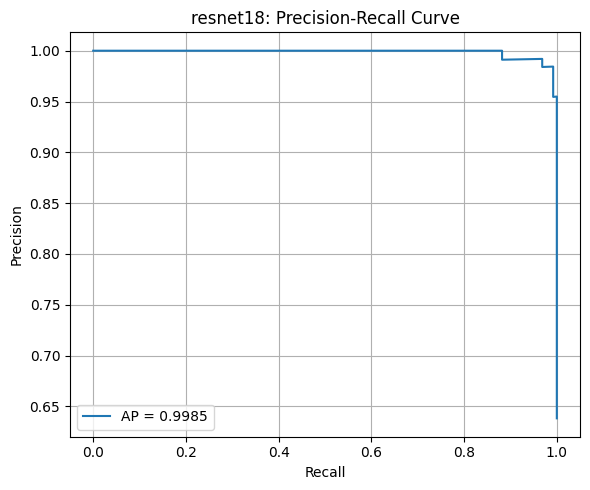

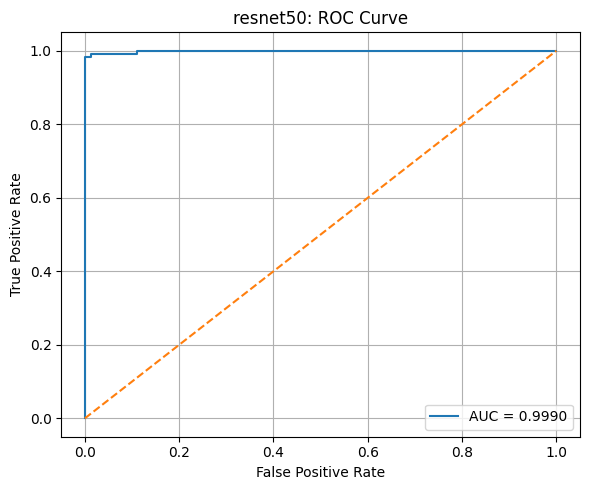

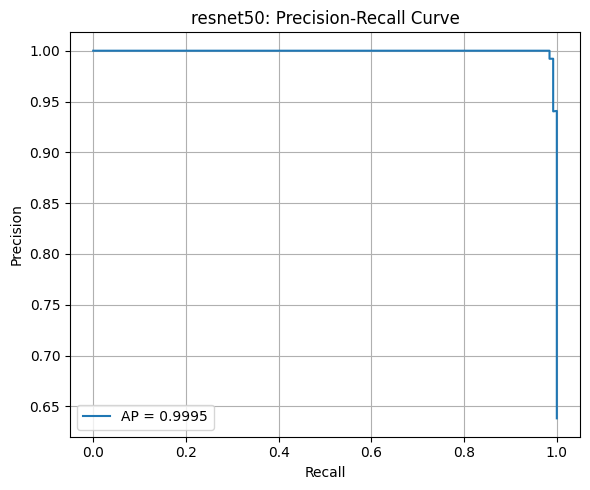

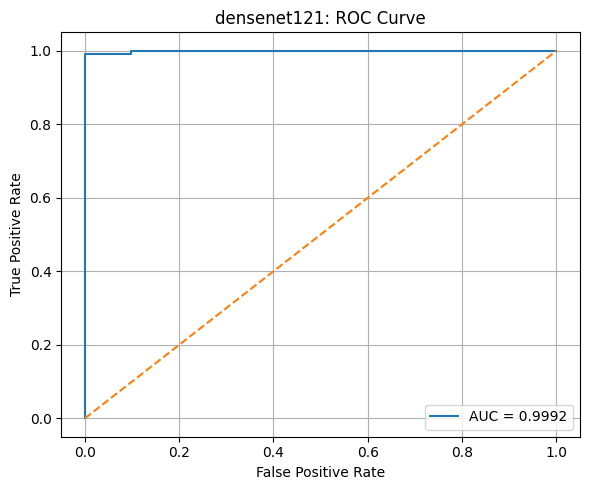

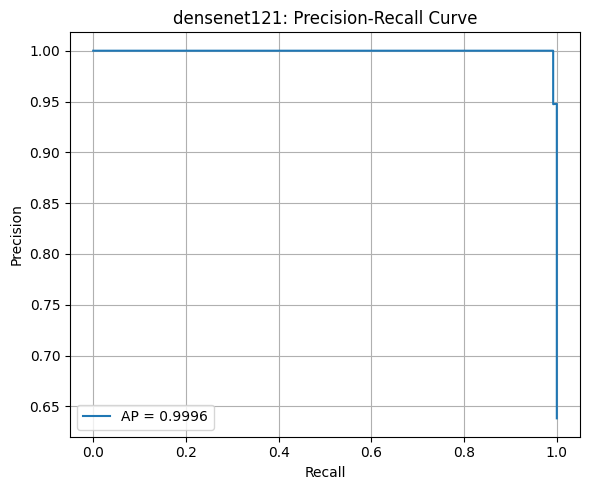

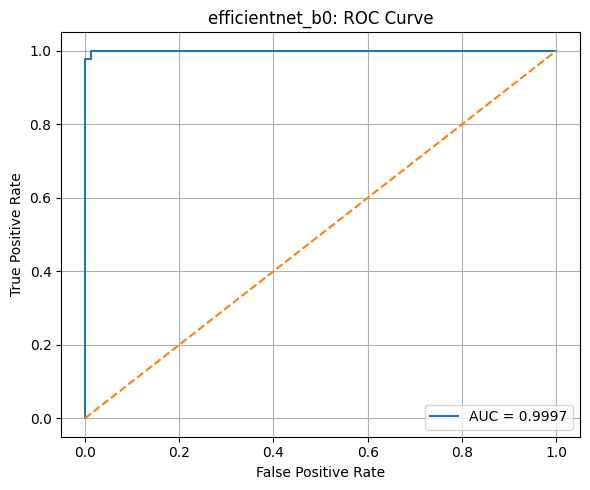

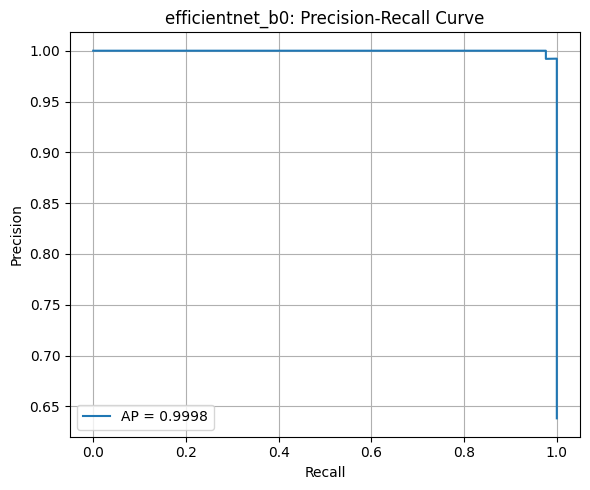

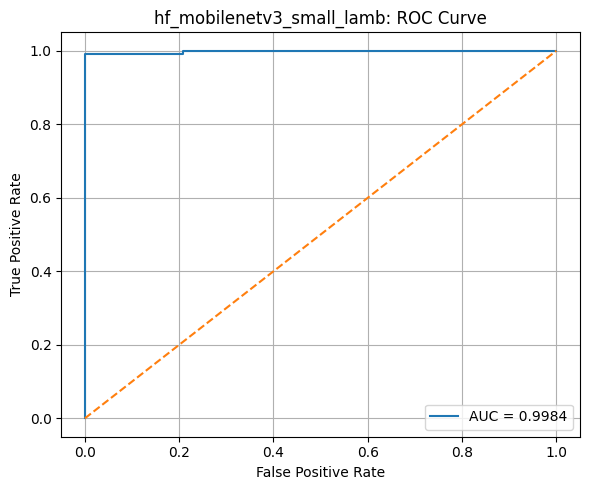

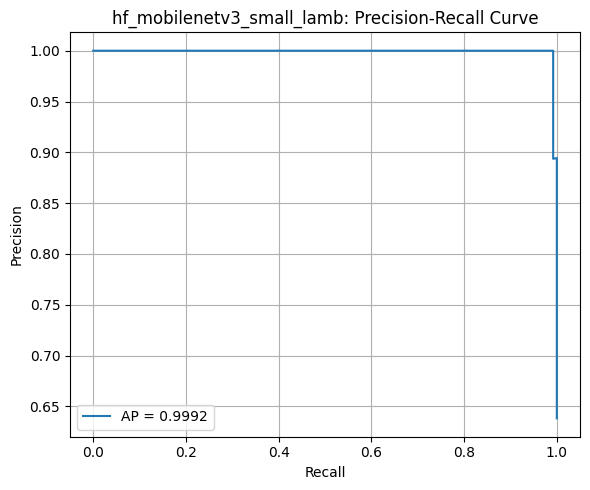

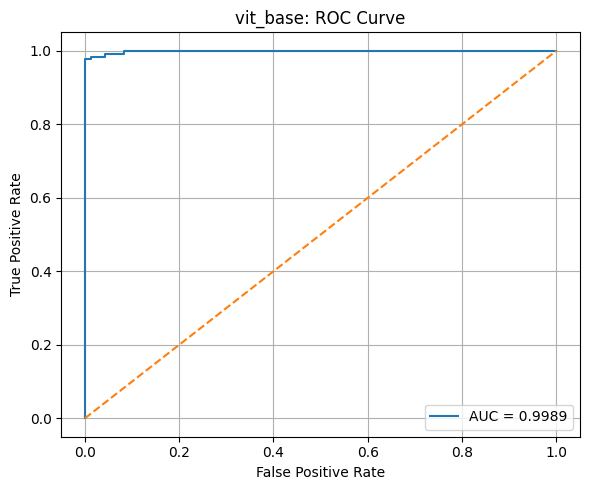

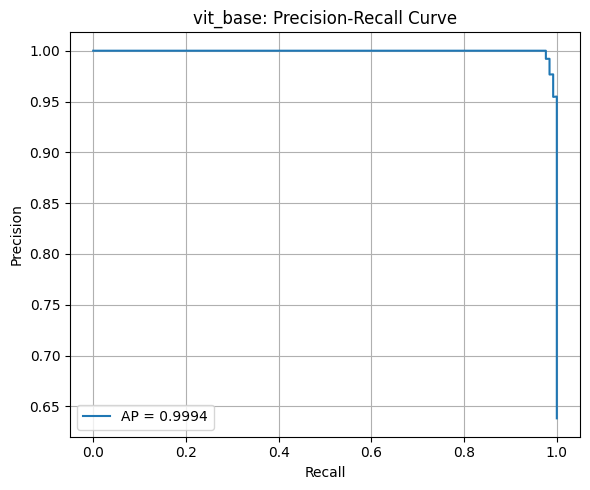

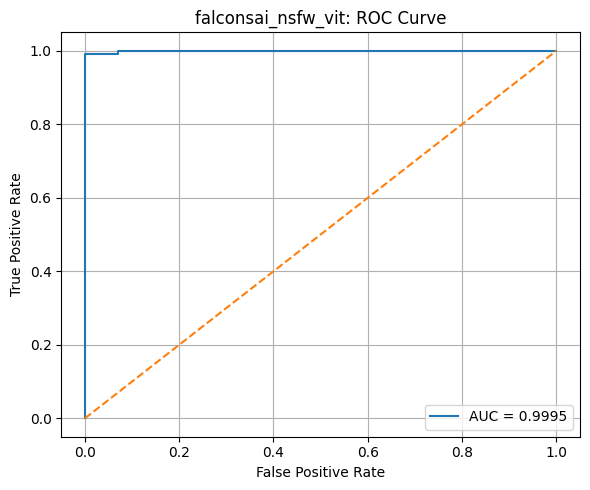

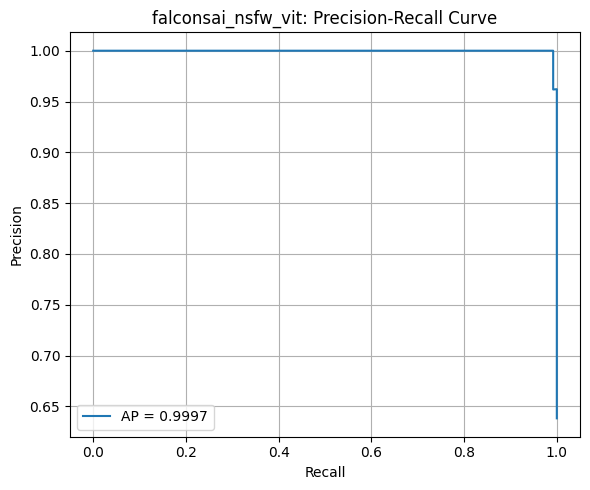

In [14]:
# Cell 14: ROC and PR curves

from sklearn.metrics import roc_curve, precision_recall_curve, auc

for model_name, item in pred_store.items():
    y_true = item["y_true"]
    y_prob = item["y_prob"]

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    precision, recall, _ = precision_recall_curve(y_true, y_prob)

    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f"AUC = {auc(fpr, tpr):.4f}")
    plt.plot([0,1], [0,1], linestyle="--")
    plt.title(f"{model_name}: ROC Curve")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6,5))
    plt.plot(recall, precision, label=f"AP = {average_precision_score(y_true, y_prob):.4f}")
    plt.title(f"{model_name}: Precision-Recall Curve")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [15]:
# Cell 15: Copy-paste classification reports

for model_name, item in pred_store.items():
    print("\n" + "="*100)
    print(model_name)
    print("="*100)
    print(classification_report(
        item["y_true"],
        item["y_pred"],
        target_names=class_names,
        digits=4
    ))


alexnet
              precision    recall  f1-score   support

   FreshFish     0.9351    1.0000    0.9664        72
InfectedFish     1.0000    0.9606    0.9799       127

    accuracy                         0.9749       199
   macro avg     0.9675    0.9803    0.9732       199
weighted avg     0.9765    0.9749    0.9750       199


vgg16
              precision    recall  f1-score   support

   FreshFish     0.9324    0.9583    0.9452        72
InfectedFish     0.9760    0.9606    0.9683       127

    accuracy                         0.9598       199
   macro avg     0.9542    0.9595    0.9567       199
weighted avg     0.9602    0.9598    0.9599       199


vgg19
              precision    recall  f1-score   support

   FreshFish     0.9730    1.0000    0.9863        72
InfectedFish     1.0000    0.9843    0.9921       127

    accuracy                         0.9899       199
   macro avg     0.9865    0.9921    0.9892       199
weighted avg     0.9902    0.9899    0.9900       1

In [16]:
# Cell 16: Hybrid ensemble

top_models = results_df.sort_values("F1-score", ascending=False)["Model"].head(3).tolist()
print("Top models used for hybrid ensemble:", top_models)

y_true = pred_store[top_models[0]]["y_true"]
avg_prob = np.mean([pred_store[m]["y_prob"] for m in top_models], axis=0)
avg_pred = (avg_prob >= 0.5).astype(int)

ensemble_metrics = compute_metrics(y_true, avg_pred, avg_prob)
ensemble_metrics["Model"] = "Hybrid_Probability_Ensemble_Top3"
ensemble_metrics["Test Loss"] = np.nan

ensemble_df = pd.DataFrame([ensemble_metrics])[cols]
print(ensemble_df.round(4).to_string(index=False))

Top models used for hybrid ensemble: ['falconsai_nsfw_vit', 'densenet121', 'hf_mobilenetv3_small_lamb']
                           Model  Test Loss  Accuracy  Precision  Recall/Sensitivity  Specificity  F1-score  Balanced Accuracy    MCC  Cohen Kappa  ROC-AUC  PR-AUC  Brier Score  TP  TN  FP  FN
Hybrid_Probability_Ensemble_Top3        NaN     0.995        1.0              0.9921          1.0     0.996             0.9961 0.9892       0.9892   0.9992  0.9996       0.0056 126  72   0   1


In [17]:
# Cell 17: McNemar statistical test


best_two = results_df.sort_values("F1-score", ascending=False)["Model"].head(2).tolist()

m1, m2 = best_two

y_true = pred_store[m1]["y_true"]
p1 = pred_store[m1]["y_pred"]
p2 = pred_store[m2]["y_pred"]

correct1 = p1 == y_true
correct2 = p2 == y_true

table = [
    [np.sum(correct1 & correct2), np.sum(correct1 & ~correct2)],
    [np.sum(~correct1 & correct2), np.sum(~correct1 & ~correct2)]
]

result = mcnemar(table, exact=True)

print("Compared models:", m1, "vs", m2)
print("McNemar contingency table:", table)
print("Statistic:", result.statistic)
print("p-value:", result.pvalue)

Compared models: falconsai_nsfw_vit vs densenet121
McNemar contingency table: [[np.int64(198), np.int64(0)], [np.int64(0), np.int64(1)]]
Statistic: 0.0
p-value: 1.0


In [18]:
# Cell 18: Inference speed benchmark

def benchmark_model(model, loader):
    model.eval()
    n = 0

    if DEVICE == "cuda":
        torch.cuda.synchronize()

    start = time.time()

    with torch.no_grad():
        for x, _ in loader:
            x = x.to(DEVICE)
            _ = forward_logits(model, x)
            n += x.size(0)

    if DEVICE == "cuda":
        torch.cuda.synchronize()

    elapsed = time.time() - start

    return {
        "Images": n,
        "Total Time (s)": elapsed,
        "Images/sec": n / elapsed,
        "ms/image": (elapsed / n) * 1000
    }


benchmarks = []

for model_name, model in trained_models.items():
    b = benchmark_model(model, test_loader)
    b["Model"] = model_name
    benchmarks.append(b)

bench_df = pd.DataFrame(benchmarks)
print(bench_df.round(4).to_string(index=False))
bench_df.to_csv("/content/salmon_inference_benchmark.csv", index=False)

 Images  Total Time (s)  Images/sec  ms/image                     Model
    199          1.3301    149.6074    6.6842                   alexnet
    199          1.7012    116.9792    8.5485                     vgg16
    199          1.8908    105.2450    9.5016                     vgg19
    199          1.3459    147.8601    6.7631                  resnet18
    199          1.4410    138.1005    7.2411                  resnet50
    199          1.8144    109.6778    9.1176               densenet121
    199          2.4270     81.9941   12.1960           efficientnet_b0
    199          1.4091    141.2241    7.0809 hf_mobilenetv3_small_lamb
    199          3.2696     60.8642   16.4300                  vit_base
    199          3.2648     60.9536   16.4059        falconsai_nsfw_vit


In [19]:
# Cell 19: YOLO26 classifier

from ultralytics import YOLO

yolo_model = YOLO("yolo26n-cls.pt")

yolo_results = yolo_model.train(
    data=str(WORK_DIR),
    epochs=30,
    imgsz=224,
    batch=32,
    device=0 if torch.cuda.is_available() else "cpu",
    project="/content/yolo26_salmon",
    name="yolo26n_cls_salmon",
    seed=SEED
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/salmon_ready, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, i

In [20]:
# Cell 20: YOLO26 validation

best_yolo_path = "/content/yolo26_salmon/yolo26n_cls_salmon/weights/best.pt"

best_yolo = YOLO(best_yolo_path)

yolo_metrics = best_yolo.val(
    data=str(WORK_DIR),
    split="test",
    imgsz=224,
    device=0 if torch.cuda.is_available() else "cpu"
)

print("YOLO26 Top-1 Accuracy:", yolo_metrics.top1)
print("YOLO26 Top-5 Accuracy:", yolo_metrics.top5)

Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n-cls summary (fused): 47 layers, 1,528,586 parameters, 0 gradients, 3.2 GFLOPs
train: /content/salmon_ready/train... found 925 images in 2 classes ✅ 
val: /content/salmon_ready/val... found 198 images in 2 classes ✅ 
test: /content/salmon_ready/test... found 199 images in 2 classes ✅ 
test: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2582.6±647.8 MB/s, size: 393.2 KB)
test: Scanning /content/salmon_ready/test... 199 images, 0 corrupt: 100% ━━━━━━━━━━━━ 199/199 1.7Kit/s 0.1s
test: New cache created: /content/salmon_ready/test.cache
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 13/13 7.1it/s 1.8s
                   all      0.975          1
Speed: 0.5ms preprocess, 2.7ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to /content/runs/classify/val
YOLO26 Top-1 Accuracy: 0.9748743772506714
YOLO26 Top-5 Accuracy: 1.0


In [21]:
# Cell 21: Export all publication tables

final_results_df = pd.concat([results_df, ensemble_df], ignore_index=True)

with pd.ExcelWriter("/content/salmon_publication_results_full.xlsx") as writer:
    dist_df.to_excel(writer, sheet_name="Dataset_Distribution", index=False)
    final_results_df.to_excel(writer, sheet_name="Model_Test_Metrics", index=False)
    bench_df.to_excel(writer, sheet_name="Inference_Benchmark", index=False)

print("Saved: /content/salmon_publication_results_full.xlsx")
print(final_results_df.round(4).to_string(index=False))

Saved: /content/salmon_publication_results_full.xlsx
                           Model  Test Loss  Accuracy  Precision  Recall/Sensitivity  Specificity  F1-score  Balanced Accuracy    MCC  Cohen Kappa  ROC-AUC  PR-AUC  Brier Score  TP  TN  FP  FN
                         alexnet     0.0997    0.9749     1.0000              0.9606       1.0000    0.9799             0.9803 0.9478       0.9464   0.9967  0.9982       0.0238 122  72   0   5
                           vgg16     0.0682    0.9598     0.9760              0.9606       0.9583    0.9683             0.9595 0.9137       0.9135   0.9970  0.9984       0.0246 122  69   3   5
                           vgg19     0.0267    0.9899     1.0000              0.9843       1.0000    0.9921             0.9921 0.9786       0.9784   0.9996  0.9998       0.0082 125  72   0   2
                        resnet18     0.0617    0.9849     0.9844              0.9921       0.9722    0.9882             0.9822 0.9673       0.9673   0.9975  0.9985       0.015

In [22]:
# Cell 22A: Robust Google Drive mount

from google.colab import drive
from pathlib import Path
import shutil, os

# First try normal mount
try:
    drive.mount('/content/drive', force_remount=True)
except Exception as e:
    print("Normal mount failed:", e)
    print("Trying Drive flush and remount...")

    try:
        drive.flush_and_unmount()
    except:
        pass

    drive.mount('/content/drive', force_remount=True)

SAVE_ROOT = Path("/content/drive/MyDrive/technicalwriting/Salmon_fish_disease_classification")

MODEL_DIR = SAVE_ROOT / "best_models"
TABLE_DIR = SAVE_ROOT / "result_tables"
IMAGE_DIR = SAVE_ROOT / "image_results"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)
IMAGE_DIR.mkdir(parents=True, exist_ok=True)

print("Saving to:", SAVE_ROOT)

Mounted at /content/drive
Saving to: /content/drive/MyDrive/technicalwriting/Salmon_fish_disease_classification


Newly Included Tests on May 29, 2026

In [23]:
# ============================================================
# Cell 23: Create folders for advanced statistical analysis
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

STAT_DIR = Path("/content/statistical_analysis")
STAT_DIR.mkdir(parents=True, exist_ok=True)

STAT_TABLE_DIR = STAT_DIR / "tables"
STAT_IMAGE_DIR = STAT_DIR / "figures"

STAT_TABLE_DIR.mkdir(parents=True, exist_ok=True)
STAT_IMAGE_DIR.mkdir(parents=True, exist_ok=True)

print("Statistical analysis folder:", STAT_DIR)
print("Tables:", STAT_TABLE_DIR)
print("Figures:", STAT_IMAGE_DIR)

Statistical analysis folder: /content/statistical_analysis
Tables: /content/statistical_analysis/tables
Figures: /content/statistical_analysis/figures


In [24]:
# ============================================================
# Cell 24: Bootstrap 95% confidence intervals for model metrics
# ============================================================

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    balanced_accuracy_score, matthews_corrcoef, cohen_kappa_score,
    roc_auc_score, average_precision_score, brier_score_loss
)

N_BOOTSTRAP = 2000
BOOT_SEED = 42
rng = np.random.default_rng(BOOT_SEED)

def safe_metric(metric_func, y_true, y_pred=None, y_prob=None):
    try:
        if y_prob is not None:
            return metric_func(y_true, y_prob)
        else:
            return metric_func(y_true, y_pred)
    except Exception:
        return np.nan

def compute_metric_dict(y_true, y_pred, y_prob):
    return {
        "Accuracy": safe_metric(accuracy_score, y_true, y_pred=y_pred),
        "Precision": safe_metric(
            lambda yt, yp: precision_score(yt, yp, zero_division=0),
            y_true, y_pred=y_pred
        ),
        "Recall": safe_metric(
            lambda yt, yp: recall_score(yt, yp, zero_division=0),
            y_true, y_pred=y_pred
        ),
        "F1-score": safe_metric(
            lambda yt, yp: f1_score(yt, yp, zero_division=0),
            y_true, y_pred=y_pred
        ),
        "Balanced Accuracy": safe_metric(balanced_accuracy_score, y_true, y_pred=y_pred),
        "MCC": safe_metric(matthews_corrcoef, y_true, y_pred=y_pred),
        "Cohen Kappa": safe_metric(cohen_kappa_score, y_true, y_pred=y_pred),
        "ROC-AUC": safe_metric(roc_auc_score, y_true, y_prob=y_prob),
        "PR-AUC": safe_metric(average_precision_score, y_true, y_prob=y_prob),
        "Brier Score": safe_metric(brier_score_loss, y_true, y_prob=y_prob)
    }

bootstrap_rows = []

for model_name, item in pred_store.items():
    y_true = np.array(item["y_true"])
    y_pred = np.array(item["y_pred"])
    y_prob = np.array(item["y_prob"])

    n = len(y_true)

    metric_samples = {
        "Accuracy": [],
        "Precision": [],
        "Recall": [],
        "F1-score": [],
        "Balanced Accuracy": [],
        "MCC": [],
        "Cohen Kappa": [],
        "ROC-AUC": [],
        "PR-AUC": [],
        "Brier Score": []
    }

    for _ in range(N_BOOTSTRAP):
        idx = rng.choice(np.arange(n), size=n, replace=True)

        yt = y_true[idx]
        yp = y_pred[idx]
        ypb = y_prob[idx]

        # AUC is undefined if only one class appears in the bootstrap sample
        if len(np.unique(yt)) < 2:
            continue

        m = compute_metric_dict(yt, yp, ypb)

        for k in metric_samples.keys():
            metric_samples[k].append(m[k])

    point_metrics = compute_metric_dict(y_true, y_pred, y_prob)

    for metric_name, values in metric_samples.items():
        values = np.array(values, dtype=float)
        values = values[~np.isnan(values)]

        if len(values) == 0:
            ci_low, ci_high, boot_mean, boot_std = np.nan, np.nan, np.nan, np.nan
        else:
            ci_low = np.percentile(values, 2.5)
            ci_high = np.percentile(values, 97.5)
            boot_mean = np.mean(values)
            boot_std = np.std(values)

        bootstrap_rows.append({
            "Model": model_name,
            "Metric": metric_name,
            "Point Estimate": point_metrics[metric_name],
            "Bootstrap Mean": boot_mean,
            "Bootstrap SD": boot_std,
            "95% CI Lower": ci_low,
            "95% CI Upper": ci_high,
            "Bootstrap Samples Used": len(values)
        })

bootstrap_ci_df = pd.DataFrame(bootstrap_rows)

print(bootstrap_ci_df.round(4).to_string(index=False))

bootstrap_ci_df.to_csv(STAT_TABLE_DIR / "bootstrap_95CI_all_metrics.csv", index=False)
bootstrap_ci_df.to_excel(STAT_TABLE_DIR / "bootstrap_95CI_all_metrics.xlsx", index=False)

print("\nSaved bootstrap confidence intervals.")

                    Model            Metric  Point Estimate  Bootstrap Mean  Bootstrap SD  95% CI Lower  95% CI Upper  Bootstrap Samples Used
                  alexnet          Accuracy          0.9749          0.9750        0.0111        0.9497        0.9950                    2000
                  alexnet         Precision          1.0000          1.0000        0.0000        1.0000        1.0000                    2000
                  alexnet            Recall          0.9606          0.9609        0.0172        0.9242        0.9921                    2000
                  alexnet          F1-score          0.9799          0.9800        0.0090        0.9606        0.9960                    2000
                  alexnet Balanced Accuracy          0.9803          0.9804        0.0086        0.9621        0.9961                    2000
                  alexnet               MCC          0.9478          0.9481        0.0225        0.9010        0.9892                    2000
      

In [25]:
# ============================================================
# Cell 25: Publication-ready metric table with 95% CIs
# ============================================================

selected_metrics = [
    "Accuracy",
    "F1-score",
    "Balanced Accuracy",
    "MCC",
    "ROC-AUC",
    "PR-AUC",
    "Brier Score"
]

pub_rows = []

for model_name in pred_store.keys():
    row = {"Model": model_name}

    for metric in selected_metrics:
        sub = bootstrap_ci_df[
            (bootstrap_ci_df["Model"] == model_name) &
            (bootstrap_ci_df["Metric"] == metric)
        ]

        if len(sub) > 0:
            pe = sub["Point Estimate"].values[0]
            lo = sub["95% CI Lower"].values[0]
            hi = sub["95% CI Upper"].values[0]

            row[metric + " (95% CI)"] = f"{pe:.4f} [{lo:.4f}, {hi:.4f}]"
        else:
            row[metric + " (95% CI)"] = "NA"

    pub_rows.append(row)

publication_ci_table = pd.DataFrame(pub_rows)

print(publication_ci_table.to_string(index=False))

publication_ci_table.to_csv(
    STAT_TABLE_DIR / "publication_metric_table_with_95CI.csv",
    index=False
)

publication_ci_table.to_excel(
    STAT_TABLE_DIR / "publication_metric_table_with_95CI.xlsx",
    index=False
)

print("\nSaved publication-ready confidence interval table.")

                    Model       Accuracy (95% CI)       F1-score (95% CI) Balanced Accuracy (95% CI)            MCC (95% CI)        ROC-AUC (95% CI)         PR-AUC (95% CI)    Brier Score (95% CI)
                  alexnet 0.9749 [0.9497, 0.9950] 0.9799 [0.9606, 0.9960]    0.9803 [0.9621, 0.9961] 0.9478 [0.9010, 0.9892] 0.9967 [0.9920, 0.9997] 0.9982 [0.9955, 0.9998] 0.0238 [0.0068, 0.0439]
                    vgg16 0.9598 [0.9296, 0.9849] 0.9683 [0.9440, 0.9882]    0.9595 [0.9290, 0.9853] 0.9137 [0.8508, 0.9677] 0.9970 [0.9924, 0.9996] 0.9984 [0.9958, 0.9998] 0.0246 [0.0101, 0.0420]
                    vgg19 0.9899 [0.9749, 1.0000] 0.9921 [0.9787, 1.0000]    0.9921 [0.9792, 1.0000] 0.9786 [0.9462, 1.0000] 0.9996 [0.9983, 1.0000] 0.9998 [0.9990, 1.0000] 0.0082 [0.0014, 0.0177]
                 resnet18 0.9849 [0.9648, 1.0000] 0.9882 [0.9728, 1.0000]    0.9822 [0.9586, 1.0000] 0.9673 [0.9250, 1.0000] 0.9975 [0.9926, 1.0000] 0.9985 [0.9958, 1.0000] 0.0151 [0.0013, 0.0325]
               

In [26]:
# ============================================================
# Cell 26: Pairwise McNemar tests with Holm-Bonferroni correction
# ============================================================

from itertools import combinations
from statsmodels.stats.contingency_tables import mcnemar
from statsmodels.stats.multitest import multipletests

mcnemar_rows = []

model_list = list(pred_store.keys())

for m1, m2 in combinations(model_list, 2):
    y_true = np.array(pred_store[m1]["y_true"])

    p1 = np.array(pred_store[m1]["y_pred"])
    p2 = np.array(pred_store[m2]["y_pred"])

    correct1 = p1 == y_true
    correct2 = p2 == y_true

    both_correct = np.sum(correct1 & correct2)
    m1_correct_m2_wrong = np.sum(correct1 & ~correct2)
    m1_wrong_m2_correct = np.sum(~correct1 & correct2)
    both_wrong = np.sum(~correct1 & ~correct2)

    table = [
        [both_correct, m1_correct_m2_wrong],
        [m1_wrong_m2_correct, both_wrong]
    ]

    try:
        test_result = mcnemar(table, exact=True)
        p_value = test_result.pvalue
        statistic = test_result.statistic
    except Exception:
        p_value = np.nan
        statistic = np.nan

    mcnemar_rows.append({
        "Model 1": m1,
        "Model 2": m2,
        "Both Correct": both_correct,
        "Model1 Correct Model2 Wrong": m1_correct_m2_wrong,
        "Model1 Wrong Model2 Correct": m1_wrong_m2_correct,
        "Both Wrong": both_wrong,
        "McNemar Statistic": statistic,
        "Raw p-value": p_value
    })

mcnemar_pairwise_df = pd.DataFrame(mcnemar_rows)

valid_p = mcnemar_pairwise_df["Raw p-value"].notna()

corrected_p = np.full(len(mcnemar_pairwise_df), np.nan)

if valid_p.sum() > 0:
    reject, pvals_corrected, _, _ = multipletests(
        mcnemar_pairwise_df.loc[valid_p, "Raw p-value"],
        alpha=0.05,
        method="holm"
    )

    corrected_p[valid_p] = pvals_corrected
    mcnemar_pairwise_df.loc[valid_p, "Significant after Holm correction"] = reject

mcnemar_pairwise_df["Holm-corrected p-value"] = corrected_p

print(mcnemar_pairwise_df.round(6).to_string(index=False))

mcnemar_pairwise_df.to_csv(
    STAT_TABLE_DIR / "pairwise_mcnemar_holm_tests.csv",
    index=False
)

mcnemar_pairwise_df.to_excel(
    STAT_TABLE_DIR / "pairwise_mcnemar_holm_tests.xlsx",
    index=False
)

print("\nSaved pairwise McNemar statistical comparison table.")

                  Model 1                   Model 2  Both Correct  Model1 Correct Model2 Wrong  Model1 Wrong Model2 Correct  Both Wrong  McNemar Statistic  Raw p-value Significant after Holm correction  Holm-corrected p-value
                  alexnet                     vgg16           190                            4                            1           4                1.0     0.375000                             False                1.000000
                  alexnet                     vgg19           194                            0                            3           2                0.0     0.250000                             False                1.000000
                  alexnet                  resnet18           192                            2                            4           1                2.0     0.687500                             False                1.000000
                  alexnet                  resnet50           194                            0  

In [27]:
# ============================================================
# Cell 27: Bootstrap paired comparison against best model
# ============================================================

N_BOOTSTRAP_COMPARE = 2000
rng = np.random.default_rng(42)

best_model = results_df.sort_values("F1-score", ascending=False)["Model"].iloc[0]
print("Best model selected by F1-score:", best_model)

comparison_metrics = ["Accuracy", "F1-score", "ROC-AUC", "PR-AUC"]

def metric_value(metric_name, y_true, y_pred, y_prob):
    if metric_name == "Accuracy":
        return accuracy_score(y_true, y_pred)
    elif metric_name == "F1-score":
        return f1_score(y_true, y_pred, zero_division=0)
    elif metric_name == "ROC-AUC":
        if len(np.unique(y_true)) < 2:
            return np.nan
        return roc_auc_score(y_true, y_prob)
    elif metric_name == "PR-AUC":
        return average_precision_score(y_true, y_prob)
    else:
        return np.nan

paired_rows = []

y_true_ref = np.array(pred_store[best_model]["y_true"])
n = len(y_true_ref)

for other_model in model_list:
    if other_model == best_model:
        continue

    for metric_name in comparison_metrics:

        diff_samples = []

        for _ in range(N_BOOTSTRAP_COMPARE):
            idx = rng.choice(np.arange(n), size=n, replace=True)

            yt = y_true_ref[idx]

            best_pred = np.array(pred_store[best_model]["y_pred"])[idx]
            best_prob = np.array(pred_store[best_model]["y_prob"])[idx]

            other_pred = np.array(pred_store[other_model]["y_pred"])[idx]
            other_prob = np.array(pred_store[other_model]["y_prob"])[idx]

            best_score = metric_value(metric_name, yt, best_pred, best_prob)
            other_score = metric_value(metric_name, yt, other_pred, other_prob)

            if not np.isnan(best_score) and not np.isnan(other_score):
                diff_samples.append(best_score - other_score)

        diff_samples = np.array(diff_samples)

        mean_diff = np.mean(diff_samples)
        ci_low = np.percentile(diff_samples, 2.5)
        ci_high = np.percentile(diff_samples, 97.5)

        # Two-sided empirical bootstrap p-value
        p_value = 2 * min(
            np.mean(diff_samples <= 0),
            np.mean(diff_samples >= 0)
        )
        p_value = min(p_value, 1.0)

        paired_rows.append({
            "Best Model": best_model,
            "Compared Model": other_model,
            "Metric": metric_name,
            "Mean Difference": mean_diff,
            "95% CI Lower": ci_low,
            "95% CI Upper": ci_high,
            "Bootstrap p-value": p_value,
            "Interpretation": (
                "Best model significantly better"
                if ci_low > 0 else
                "No clear superiority"
            )
        })

paired_bootstrap_df = pd.DataFrame(paired_rows)

print(paired_bootstrap_df.round(6).to_string(index=False))

paired_bootstrap_df.to_csv(
    STAT_TABLE_DIR / "paired_bootstrap_best_model_comparison.csv",
    index=False
)

paired_bootstrap_df.to_excel(
    STAT_TABLE_DIR / "paired_bootstrap_best_model_comparison.xlsx",
    index=False
)

print("\nSaved paired bootstrap comparison table.")

Best model selected by F1-score: falconsai_nsfw_vit
        Best Model            Compared Model   Metric  Mean Difference  95% CI Lower  95% CI Upper  Bootstrap p-value                  Interpretation
falconsai_nsfw_vit                   alexnet Accuracy         0.019912      0.005025      0.040201              0.039 Best model significantly better
falconsai_nsfw_vit                   alexnet F1-score         0.016370      0.003831      0.034777              0.025 Best model significantly better
falconsai_nsfw_vit                   alexnet  ROC-AUC         0.002678      0.000316      0.006467              0.022 Best model significantly better
falconsai_nsfw_vit                   alexnet   PR-AUC         0.001451      0.000156      0.003744              0.018 Best model significantly better
falconsai_nsfw_vit                     vgg16 Accuracy         0.035234      0.014950      0.060302              0.001 Best model significantly better
falconsai_nsfw_vit                     vgg16 F1-

In [28]:
# ============================================================
# Cell 28: Threshold optimization using F1 and Youden's J statistic
# ============================================================

threshold_rows = []

threshold_grid = np.linspace(0.01, 0.99, 99)

for model_name, item in pred_store.items():
    y_true = np.array(item["y_true"])
    y_prob = np.array(item["y_prob"])

    best_f1 = -1
    best_f1_threshold = 0.5
    best_j = -1
    best_j_threshold = 0.5

    for th in threshold_grid:
        y_pred_th = (y_prob >= th).astype(int)

        cm = confusion_matrix(y_true, y_pred_th)

        if cm.shape != (2, 2):
            continue

        tn, fp, fn, tp = cm.ravel()

        sensitivity = tp / (tp + fn + 1e-9)
        specificity = tn / (tn + fp + 1e-9)
        youden_j = sensitivity + specificity - 1

        f1_val = f1_score(y_true, y_pred_th, zero_division=0)

        if f1_val > best_f1:
            best_f1 = f1_val
            best_f1_threshold = th

        if youden_j > best_j:
            best_j = youden_j
            best_j_threshold = th

    pred_f1_opt = (y_prob >= best_f1_threshold).astype(int)
    pred_j_opt = (y_prob >= best_j_threshold).astype(int)

    threshold_rows.append({
        "Model": model_name,
        "Default Threshold": 0.5,
        "Best F1 Threshold": best_f1_threshold,
        "Best F1 at Optimized Threshold": f1_score(y_true, pred_f1_opt, zero_division=0),
        "Accuracy at F1 Threshold": accuracy_score(y_true, pred_f1_opt),
        "Best Youden Threshold": best_j_threshold,
        "Best Youden J": best_j,
        "Accuracy at Youden Threshold": accuracy_score(y_true, pred_j_opt),
        "F1 at Youden Threshold": f1_score(y_true, pred_j_opt, zero_division=0)
    })

threshold_optimization_df = pd.DataFrame(threshold_rows)

print(threshold_optimization_df.round(4).to_string(index=False))

threshold_optimization_df.to_csv(
    STAT_TABLE_DIR / "threshold_optimization_results.csv",
    index=False
)

threshold_optimization_df.to_excel(
    STAT_TABLE_DIR / "threshold_optimization_results.xlsx",
    index=False
)

print("\nSaved threshold optimization results.")

                    Model  Default Threshold  Best F1 Threshold  Best F1 at Optimized Threshold  Accuracy at F1 Threshold  Best Youden Threshold  Best Youden J  Accuracy at Youden Threshold  F1 at Youden Threshold
                  alexnet                0.5               0.42                          0.9799                    0.9749                   0.42         0.9606                        0.9749                  0.9799
                    vgg16                0.5               0.08                          0.9769                    0.9698                   0.87         0.9528                        0.9698                  0.9758
                    vgg19                0.5               0.30                          0.9921                    0.9899                   0.36         0.9843                        0.9899                  0.9921
                 resnet18                0.5               0.19                          0.9882                    0.9849                   0.19

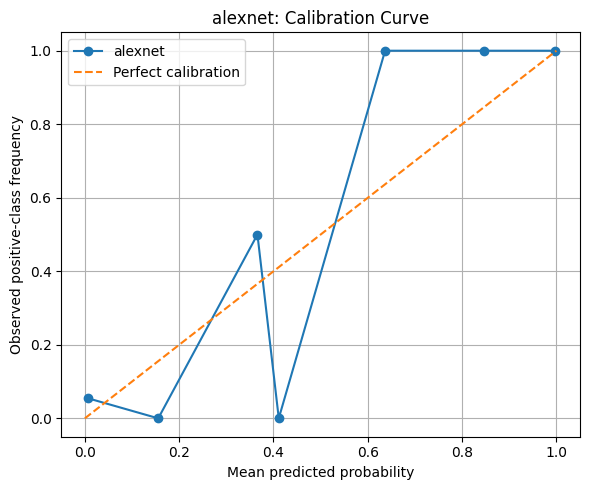

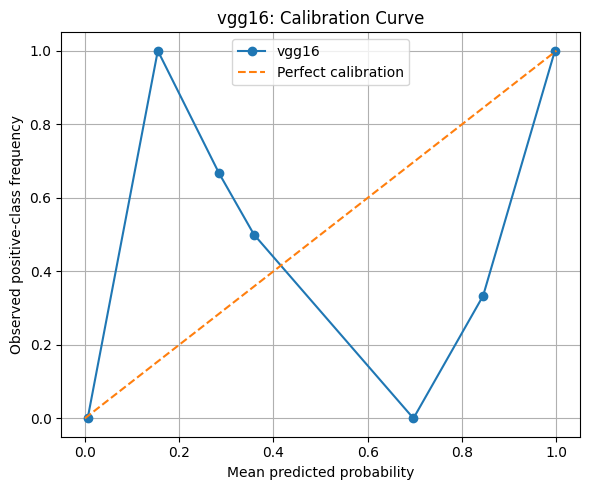

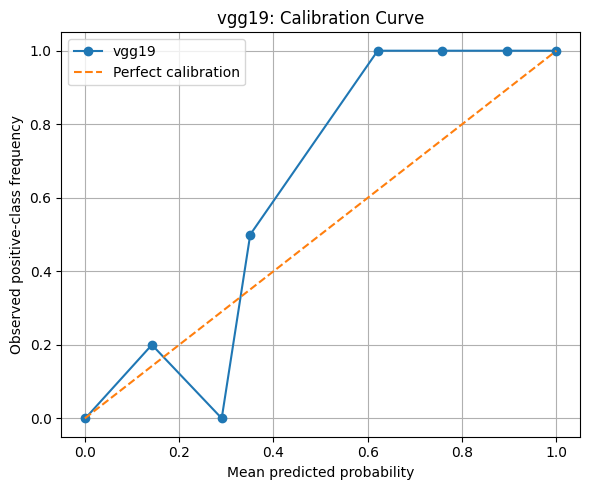

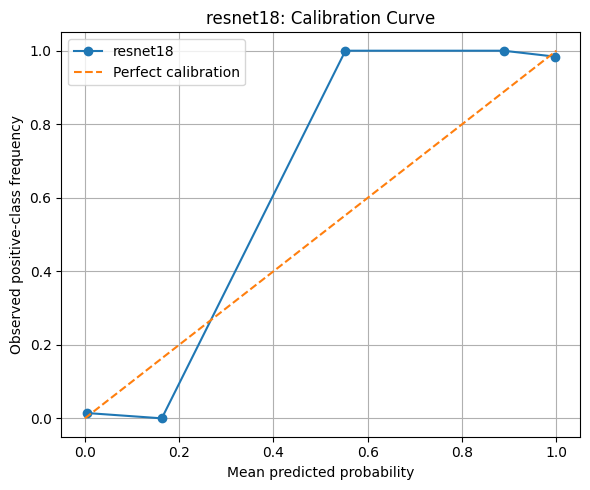

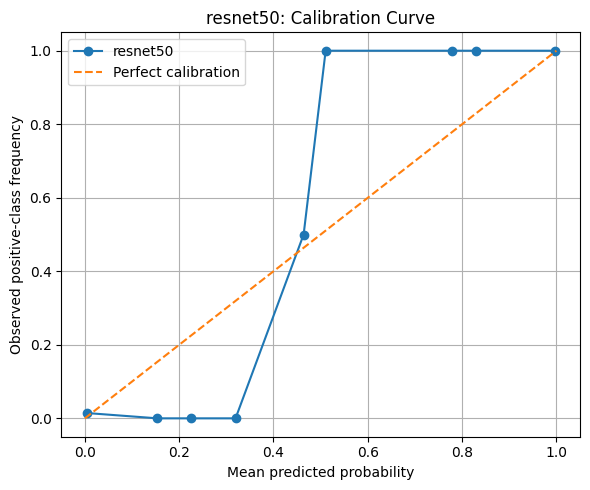

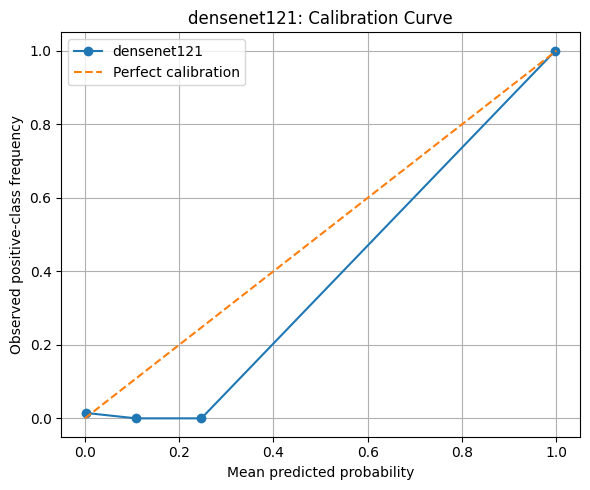

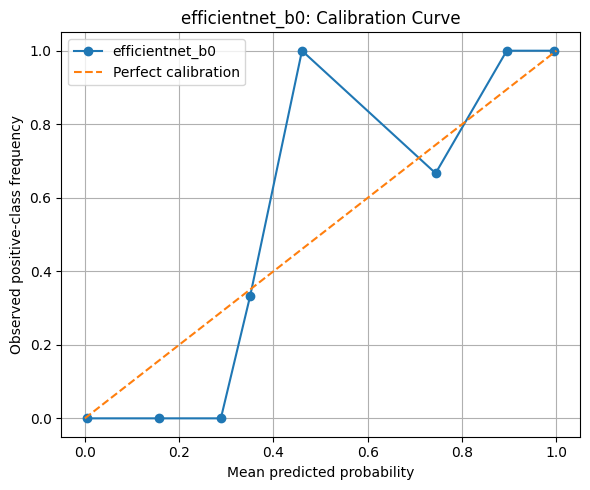

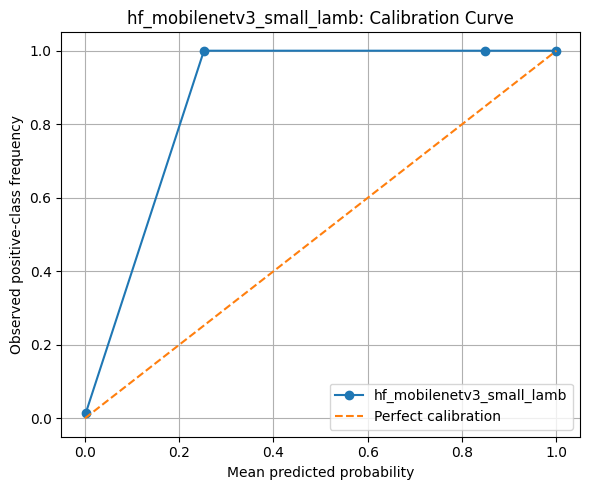

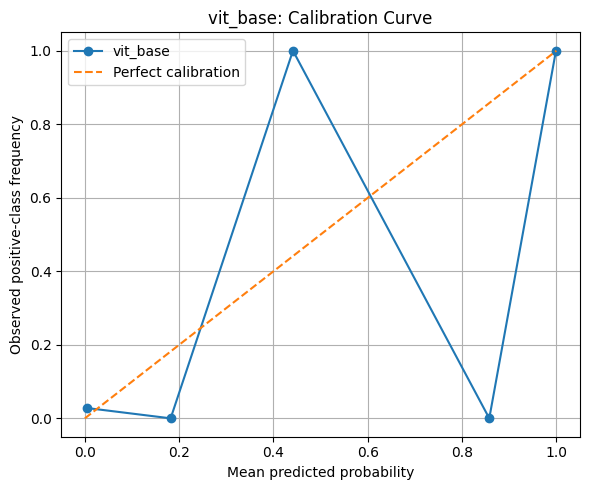

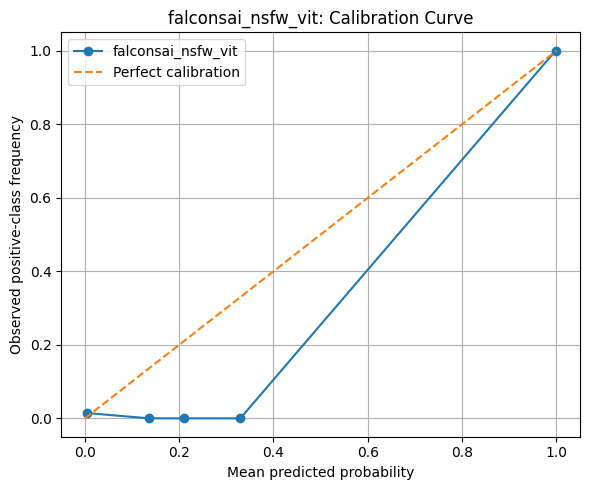

                    Model  Brier Score  Expected Calibration Error-10 bins
                  alexnet       0.0238                              0.0261
                    vgg16       0.0246                              0.0280
                    vgg19       0.0082                              0.0091
                 resnet18       0.0151                              0.0164
                 resnet50       0.0107                              0.0162
              densenet121       0.0059                              0.0106
          efficientnet_b0       0.0095                              0.0138
hf_mobilenetv3_small_lamb       0.0082                              0.0102
                 vit_base       0.0151                              0.0182
       falconsai_nsfw_vit       0.0055                              0.0088

Saved calibration metrics and figures.


In [29]:
# ============================================================
# Cell 29: Calibration analysis and Expected Calibration Error
# ============================================================

from sklearn.calibration import calibration_curve

def expected_calibration_error(y_true, y_prob, n_bins=10):
    y_true = np.array(y_true)
    y_prob = np.array(y_prob)

    bins = np.linspace(0.0, 1.0, n_bins + 1)
    bin_ids = np.digitize(y_prob, bins) - 1

    ece = 0.0

    for i in range(n_bins):
        mask = bin_ids == i
        if np.sum(mask) == 0:
            continue

        bin_confidence = np.mean(y_prob[mask])
        bin_accuracy = np.mean(y_true[mask])
        bin_weight = np.sum(mask) / len(y_true)

        ece += bin_weight * abs(bin_accuracy - bin_confidence)

    return ece

calibration_rows = []

for model_name, item in pred_store.items():
    y_true = np.array(item["y_true"])
    y_prob = np.array(item["y_prob"])

    ece_10 = expected_calibration_error(y_true, y_prob, n_bins=10)
    brier = brier_score_loss(y_true, y_prob)

    calibration_rows.append({
        "Model": model_name,
        "Brier Score": brier,
        "Expected Calibration Error-10 bins": ece_10
    })

    prob_true, prob_pred = calibration_curve(
        y_true,
        y_prob,
        n_bins=10,
        strategy="uniform"
    )

    plt.figure(figsize=(6, 5))
    plt.plot(prob_pred, prob_true, marker="o", label=model_name)
    plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
    plt.xlabel("Mean predicted probability")
    plt.ylabel("Observed positive-class frequency")
    plt.title(f"{model_name}: Calibration Curve")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(STAT_IMAGE_DIR / f"{model_name}_calibration_curve.png", dpi=300)
    plt.show()

calibration_df = pd.DataFrame(calibration_rows)

print(calibration_df.round(4).to_string(index=False))

calibration_df.to_csv(
    STAT_TABLE_DIR / "calibration_metrics.csv",
    index=False
)

calibration_df.to_excel(
    STAT_TABLE_DIR / "calibration_metrics.xlsx",
    index=False
)

print("\nSaved calibration metrics and figures.")

                    Model  Mean Rank  Median Rank  Rank Std  Accuracy Rank  Precision Rank  Recall/Sensitivity Rank  Specificity Rank  F1-score Rank  Balanced Accuracy Rank  MCC Rank  Cohen Kappa Rank  ROC-AUC Rank  PR-AUC Rank  Brier Score Rank  Test Loss Rank
       falconsai_nsfw_vit     2.0417          1.5    0.9405            1.5             3.5                      2.0               3.5            1.5                     1.5       1.5               1.5           3.0          3.0               1.0             1.0
              densenet121     2.4583          2.0    1.0544            1.5             3.5                      2.0               3.5            1.5                     1.5       1.5               1.5           4.0          4.0               2.0             3.0
                    vgg19     3.5417          4.0    1.0544            4.0             3.5                      5.5               3.5            4.0                     4.0       4.0               4.0           2.0

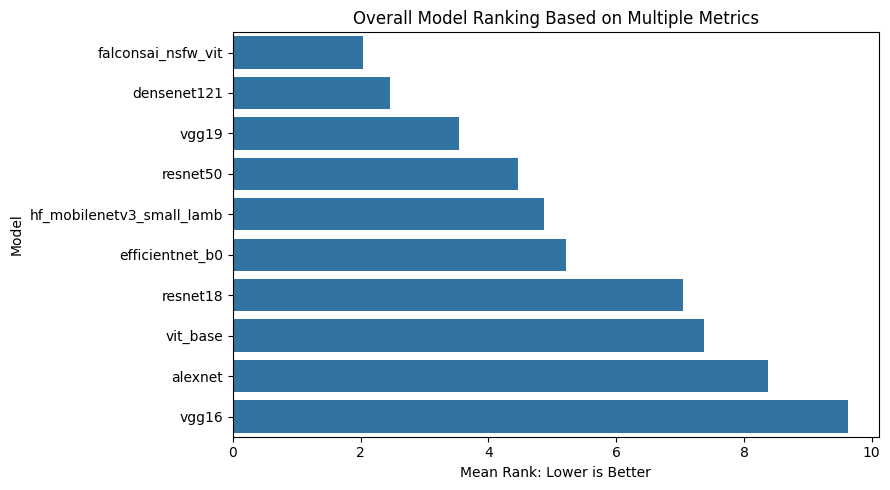

In [30]:
# ============================================================
# Cell 30: Multi-metric model ranking analysis
# ============================================================

ranking_metrics_high_good = [
    "Accuracy",
    "Precision",
    "Recall/Sensitivity",
    "Specificity",
    "F1-score",
    "Balanced Accuracy",
    "MCC",
    "Cohen Kappa",
    "ROC-AUC",
    "PR-AUC"
]

ranking_metrics_low_good = [
    "Brier Score",
    "Test Loss"
]

rank_df = results_df.copy()

for metric in ranking_metrics_high_good:
    if metric in rank_df.columns:
        rank_df[metric + " Rank"] = rank_df[metric].rank(
            ascending=False,
            method="average"
        )

for metric in ranking_metrics_low_good:
    if metric in rank_df.columns:
        rank_df[metric + " Rank"] = rank_df[metric].rank(
            ascending=True,
            method="average"
        )

rank_columns = [c for c in rank_df.columns if c.endswith("Rank")]

rank_df["Mean Rank"] = rank_df[rank_columns].mean(axis=1)
rank_df["Median Rank"] = rank_df[rank_columns].median(axis=1)
rank_df["Rank Std"] = rank_df[rank_columns].std(axis=1)

rank_summary_df = rank_df[
    ["Model", "Mean Rank", "Median Rank", "Rank Std"] + rank_columns
].sort_values("Mean Rank")

print(rank_summary_df.round(4).to_string(index=False))

rank_summary_df.to_csv(
    STAT_TABLE_DIR / "multi_metric_model_ranking.csv",
    index=False
)

rank_summary_df.to_excel(
    STAT_TABLE_DIR / "multi_metric_model_ranking.xlsx",
    index=False
)

plt.figure(figsize=(9, 5))
sns.barplot(
    data=rank_summary_df,
    x="Mean Rank",
    y="Model"
)
plt.title("Overall Model Ranking Based on Multiple Metrics")
plt.xlabel("Mean Rank: Lower is Better")
plt.ylabel("Model")
plt.tight_layout()
plt.savefig(STAT_IMAGE_DIR / "multi_metric_model_ranking.png", dpi=300)
plt.show()

In [31]:
# ============================================================
# Cell 31: Auto-generate statistical summary paragraph
# ============================================================

best_by_f1 = results_df.sort_values("F1-score", ascending=False).iloc[0]
best_by_auc = results_df.sort_values("ROC-AUC", ascending=False).iloc[0]
best_by_mcc = results_df.sort_values("MCC", ascending=False).iloc[0]
best_by_brier = results_df.sort_values("Brier Score", ascending=True).iloc[0]

summary_text = f"""
Statistical Performance Summary

Among the evaluated deep learning and transfer-learning models, the highest
F1-score was obtained by {best_by_f1['Model']} with an F1-score of
{best_by_f1['F1-score']:.4f}, accuracy of {best_by_f1['Accuracy']:.4f},
balanced accuracy of {best_by_f1['Balanced Accuracy']:.4f}, and MCC of
{best_by_f1['MCC']:.4f}. The strongest ROC-AUC was achieved by
{best_by_auc['Model']} with ROC-AUC = {best_by_auc['ROC-AUC']:.4f},
whereas the best MCC was achieved by {best_by_mcc['Model']} with MCC =
{best_by_mcc['MCC']:.4f}. In terms of probabilistic calibration, the lowest
Brier score was obtained by {best_by_brier['Model']} with Brier score =
{best_by_brier['Brier Score']:.4f}.

Bootstrap confidence intervals were estimated using {N_BOOTSTRAP} resamples
of the held-out test set. Pairwise McNemar tests were used to compare
classification disagreement patterns between models, and Holm correction was
applied to control the family-wise error rate across multiple pairwise
comparisons. Threshold optimization was additionally performed using both
F1-score maximization and Youden's J statistic to evaluate whether the default
0.5 decision threshold was optimal for infected-salmon detection.
"""

print(summary_text)

with open(STAT_TABLE_DIR / "statistical_summary_for_manuscript.txt", "w") as f:
    f.write(summary_text)

print("\nSaved manuscript-ready statistical summary.")


Statistical Performance Summary

Among the evaluated deep learning and transfer-learning models, the highest
F1-score was obtained by falconsai_nsfw_vit with an F1-score of
0.9960, accuracy of 0.9950,
balanced accuracy of 0.9961, and MCC of
0.9892. The strongest ROC-AUC was achieved by
efficientnet_b0 with ROC-AUC = 0.9997,
whereas the best MCC was achieved by falconsai_nsfw_vit with MCC =
0.9892. In terms of probabilistic calibration, the lowest
Brier score was obtained by falconsai_nsfw_vit with Brier score =
0.0055.

Bootstrap confidence intervals were estimated using 2000 resamples
of the held-out test set. Pairwise McNemar tests were used to compare
classification disagreement patterns between models, and Holm correction was
applied to control the family-wise error rate across multiple pairwise
comparisons. Threshold optimization was additionally performed using both
F1-score maximization and Youden's J statistic to evaluate whether the default
0.5 decision threshold was optimal 

In [32]:
# ============================================================
# Cell 32: Copy statistical outputs to Google Drive if available
# ============================================================

import shutil
from pathlib import Path

try:
    DRIVE_STAT_DIR = SAVE_ROOT / "statistical_analysis"
    DRIVE_STAT_DIR.mkdir(parents=True, exist_ok=True)

    for item in STAT_DIR.rglob("*"):
        if item.is_file():
            relative_path = item.relative_to(STAT_DIR)
            destination = DRIVE_STAT_DIR / relative_path
            destination.parent.mkdir(parents=True, exist_ok=True)
            shutil.copy2(item, destination)

    print("Statistical analysis outputs copied to Google Drive:")
    print(DRIVE_STAT_DIR)

except Exception as e:
    print("Google Drive copy skipped.")
    print("Reason:", e)

Statistical analysis outputs copied to Google Drive:
/content/drive/MyDrive/technicalwriting/Salmon_fish_disease_classification/statistical_analysis


In [33]:
# Save best PyTorch model weights

for model_name in trained_models.keys():
    src = Path(f"/content/best_{model_name}.pt")
    dst = MODEL_DIR / f"best_{model_name}.pt"

    if src.exists():
        shutil.copy2(src, dst)
        print("Saved model:", dst)
    else:
        print("Model not found:", src)

Saved model: /content/drive/MyDrive/technicalwriting/Salmon_fish_disease_classification/best_models/best_alexnet.pt
Saved model: /content/drive/MyDrive/technicalwriting/Salmon_fish_disease_classification/best_models/best_vgg16.pt
Saved model: /content/drive/MyDrive/technicalwriting/Salmon_fish_disease_classification/best_models/best_vgg19.pt
Saved model: /content/drive/MyDrive/technicalwriting/Salmon_fish_disease_classification/best_models/best_resnet18.pt
Saved model: /content/drive/MyDrive/technicalwriting/Salmon_fish_disease_classification/best_models/best_resnet50.pt
Saved model: /content/drive/MyDrive/technicalwriting/Salmon_fish_disease_classification/best_models/best_densenet121.pt
Saved model: /content/drive/MyDrive/technicalwriting/Salmon_fish_disease_classification/best_models/best_efficientnet_b0.pt
Saved model: /content/drive/MyDrive/technicalwriting/Salmon_fish_disease_classification/best_models/best_hf_mobilenetv3_small_lamb.pt
Saved model: /content/drive/MyDrive/technica

In [34]:
# Save YOLO26 best model if available

yolo_best_src = Path("/content/yolo26_salmon/yolo26n_cls_salmon/weights/best.pt")
yolo_last_src = Path("/content/yolo26_salmon/yolo26n_cls_salmon/weights/last.pt")

if yolo_best_src.exists():
    shutil.copy2(yolo_best_src, MODEL_DIR / "best_yolo26n_cls_salmon.pt")
    print("Saved YOLO best model.")

if yolo_last_src.exists():
    shutil.copy2(yolo_last_src, MODEL_DIR / "last_yolo26n_cls_salmon.pt")
    print("Saved YOLO last model.")

Saved YOLO best model.
Saved YOLO last model.


In [35]:
# Save all CSV and Excel result tables

csv_files = list(Path("/content").glob("*.csv"))
excel_files = list(Path("/content").glob("*.xlsx"))

for f in csv_files + excel_files:
    shutil.copy2(f, TABLE_DIR / f.name)
    print("Saved table:", TABLE_DIR / f.name)

# Also save final dataframes again safely
dist_df.to_csv(TABLE_DIR / "dataset_distribution.csv", index=False)
results_df.to_csv(TABLE_DIR / "model_test_metrics.csv", index=False)
bench_df.to_csv(TABLE_DIR / "inference_benchmark.csv", index=False)

with pd.ExcelWriter(TABLE_DIR / "salmon_publication_results_full.xlsx") as writer:
    dist_df.to_excel(writer, sheet_name="Dataset_Distribution", index=False)
    results_df.to_excel(writer, sheet_name="Model_Test_Metrics", index=False)
    bench_df.to_excel(writer, sheet_name="Inference_Benchmark", index=False)

print("All result tables saved.")

Saved table: /content/drive/MyDrive/technicalwriting/Salmon_fish_disease_classification/result_tables/salmon_model_test_metrics.csv
Saved table: /content/drive/MyDrive/technicalwriting/Salmon_fish_disease_classification/result_tables/salmon_inference_benchmark.csv
Saved table: /content/drive/MyDrive/technicalwriting/Salmon_fish_disease_classification/result_tables/salmon_publication_results_full.xlsx
All result tables saved.


In [36]:
# Save training curves as images

for model_name, hist in all_histories.items():

    plt.figure(figsize=(7,4))
    plt.plot(hist["epoch"], hist["train_loss"], marker="o", label="Train Loss")
    plt.plot(hist["epoch"], hist["val_loss"], marker="o", label="Validation Loss")
    plt.title(f"{model_name}: Loss Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(IMAGE_DIR / f"{model_name}_loss_curve.png", dpi=300)
    plt.close()

    plt.figure(figsize=(7,4))
    plt.plot(hist["epoch"], hist["train_acc"], marker="o", label="Train Accuracy")
    plt.plot(hist["epoch"], hist["val_acc"], marker="o", label="Validation Accuracy")
    plt.title(f"{model_name}: Accuracy Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(IMAGE_DIR / f"{model_name}_accuracy_curve.png", dpi=300)
    plt.close()

print("Training curves saved.")

Training curves saved.


In [37]:
# Save confusion matrices

for model_name, item in pred_store.items():
    cm = confusion_matrix(item["y_true"], item["y_pred"])

    plt.figure(figsize=(5,4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )
    plt.title(f"{model_name}: Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.savefig(IMAGE_DIR / f"{model_name}_confusion_matrix.png", dpi=300)
    plt.close()

print("Confusion matrices saved.")

Confusion matrices saved.


In [38]:
# Save ROC and PR curves

from sklearn.metrics import roc_curve, precision_recall_curve, auc, average_precision_score

for model_name, item in pred_store.items():
    y_true = item["y_true"]
    y_prob = item["y_prob"]

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    precision, recall, _ = precision_recall_curve(y_true, y_prob)

    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f"AUC = {auc(fpr, tpr):.4f}")
    plt.plot([0,1], [0,1], linestyle="--")
    plt.title(f"{model_name}: ROC Curve")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(IMAGE_DIR / f"{model_name}_roc_curve.png", dpi=300)
    plt.close()

    plt.figure(figsize=(6,5))
    plt.plot(recall, precision, label=f"AP = {average_precision_score(y_true, y_prob):.4f}")
    plt.title(f"{model_name}: Precision-Recall Curve")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(IMAGE_DIR / f"{model_name}_precision_recall_curve.png", dpi=300)
    plt.close()

print("ROC and PR curves saved.")

ROC and PR curves saved.


In [39]:
# Save dataset distribution figure

plt.figure(figsize=(7,4))
sns.barplot(data=dist_df, x="Split", y="Count", hue="Class")
plt.title("SalmonScan Train/Validation/Test Distribution")
plt.tight_layout()
plt.savefig(IMAGE_DIR / "dataset_distribution.png", dpi=300)
plt.close()

print("Dataset distribution figure saved.")

Dataset distribution figure saved.


In [40]:
# Save YOLO training outputs if available

YOLO_RUN_DIR = Path("/content/yolo26_salmon/yolo26n_cls_salmon")

if YOLO_RUN_DIR.exists():
    YOLO_SAVE_DIR = IMAGE_DIR / "yolo26_training_outputs"
    YOLO_SAVE_DIR.mkdir(parents=True, exist_ok=True)

    for f in YOLO_RUN_DIR.rglob("*"):
        if f.is_file() and f.suffix.lower() in [".png", ".jpg", ".jpeg", ".csv"]:
            target = YOLO_SAVE_DIR / f.name
            shutil.copy2(f, target)

    print("YOLO result images/tables saved.")
else:
    print("YOLO run folder not found.")

YOLO result images/tables saved.


In [41]:
# Final confirmation

print("\nSaved successfully.")
print("Best models:", MODEL_DIR)
print("Result tables:", TABLE_DIR)
print("Image results:", IMAGE_DIR)

print("\nFiles in best_models:")
print(list(MODEL_DIR.glob("*")))

print("\nFiles in result_tables:")
print(list(TABLE_DIR.glob("*")))

print("\nFiles in image_results:")
print(list(IMAGE_DIR.glob("*"))[:20])


Saved successfully.
Best models: /content/drive/MyDrive/technicalwriting/Salmon_fish_disease_classification/best_models
Result tables: /content/drive/MyDrive/technicalwriting/Salmon_fish_disease_classification/result_tables
Image results: /content/drive/MyDrive/technicalwriting/Salmon_fish_disease_classification/image_results

Files in best_models:
[PosixPath('/content/drive/MyDrive/technicalwriting/Salmon_fish_disease_classification/best_models/best_alexnet.pt'), PosixPath('/content/drive/MyDrive/technicalwriting/Salmon_fish_disease_classification/best_models/best_vgg16.pt'), PosixPath('/content/drive/MyDrive/technicalwriting/Salmon_fish_disease_classification/best_models/best_vgg19.pt'), PosixPath('/content/drive/MyDrive/technicalwriting/Salmon_fish_disease_classification/best_models/best_resnet18.pt'), PosixPath('/content/drive/MyDrive/technicalwriting/Salmon_fish_disease_classification/best_models/best_resnet50.pt'), PosixPath('/content/drive/MyDrive/technicalwriting/Salmon_fish_d